# Анализ пользовательского поведения и юнит-экономики маркетплейса

## Бизнес-контекст и задачи анализа

### Контекст

Быстрорастущий маркетплейс уже нашёл свою нишу и начал приносить прибыль. Компания активно инвестирует в маркетинг, привлекая новых пользователей через разные каналы. Выручка формируется как комиссия 5% от стоимости каждого заказа.

Во втором полугодии 2024 года бизнес столкнулся с тревожным сигналом: маркетинговые бюджеты выросли, а выручка пошла вниз. Команда не понимает, где именно произошёл сбой. Цель исследования — обнаружить источники проблем, точки роста и предложить гипотезы для развития продукта.

### Задачи

1. Оценить динамику ключевых метрик: вовлечённость (DAU, WAU, MAU, Stickiness), монетизацию (выручка, ARPU, ARPPU, AOV) и конверсию в платящих пользователей.
2. Проанализировать юнит-экономику по когортам: CAC, ROMI, срок окупаемости.
3. Найти проблемные сегменты: каналы привлечения, пользовательские группы, товарные категории.
4. Построить пользовательскую воронку и выявить этапы с максимальной потерей аудитории.
5. Сформулировать гипотезы для улучшения продукта и маркетинга.

### Данные

Подробное описание структуры таблиц и ссылки на файлы — в `data/data_schema.md`.

## Данные и предобработка
В проекте используются четыре основных датасета: заказы, пользователи, события и маркетинговые затраты. Подробное описание структуры таблиц и ссылки на файлы — в `data_schema.md`.

В этом разделе:
- загрузим данные и проверим их на пропуски, дубликаты и типы данных;
- создадим дополнительные признаки для анализа (агрегированный идентификатор заказа, комиссия маркетплейса);
- зафиксируем ограничения, которые повлияют на интерпретацию результатов (проблемы с логированием событий).

In [1]:
# Импортируем библиотеки
try:
    import pandas as pd
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError as e:
    print(f"Ошибка: {e}")
    print("Установите библиотеки: pip install pandas plotly")
    raise SystemExit

In [ ]:
# Загружаем датасеты
pa_marketplace_orders = pd.read_csv('https://.../datasets/pa_marketplace_orders.csv',
                                    parse_dates=['order_date', 'order_week', 'order_month'])
pa_marketplace_campaign_costs = pd.read_csv('https://.../datasets/pa_marketplace_campaign_costs.csv',
                                            usecols=['acq_channel', 'spend_month', 'budget'],
                                            parse_dates=['spend_month'])
pa_marketplace_users = pd.read_csv('https://.../datasets/pa_marketplace_users.csv',
                                  parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
pa_marketplace_events = pd.read_csv('https://.../datasets/pa_marketplace_events.csv',
                                   parse_dates=['event_date', 'event_week', 'event_month'])

In [3]:
# Создаем словарь датафреймов
tables={'pa_marketplace_orders': pa_marketplace_orders,
       'pa_marketplace_campaign_costs': pa_marketplace_campaign_costs,
       'pa_marketplace_users': pa_marketplace_users,
       'pa_marketplace_events': pa_marketplace_events}

# Создаем функцию для вывода краткой информации
def dataframe_summary(name, df):
    summary = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.values,
        'non_null': df.count().values,
        'nulls': df.isnull().sum().values,
        'nulls_%': (df.isnull().sum() / len(df) * 100).round(2).values,
        'unique': df.nunique().values
    })
    return summary

# Выводим информацию по датафреймам
for name, df in tables.items():
    print(f'Датафрейм: {name} (строк - {len(df)}, колонок - {len(df.columns)})')
    display(dataframe_summary(name, df))
    display(df.head())
    print()

Датафрейм: pa_marketplace_orders (строк - 31357, колонок - 10)


,column,dtype,non_null,nulls,nulls_%,unique
0,order_id,int64,31357,0,0.0,31357
1,user_id,int64,31357,0,0.0,8922
2,order_date,datetime64[us],31357,0,0.0,18009
3,product_name,str,31357,0,0.0,200
4,quantity,int64,31357,0,0.0,3
5,unit_price,float64,31357,0,0.0,200
6,total_price,float64,31357,0,0.0,600
7,category_name,str,31357,0,0.0,25
8,order_week,datetime64[us],31357,0,0.0,53
9,order_month,datetime64[us],31357,0,0.0,12


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01



Датафрейм: pa_marketplace_campaign_costs (строк - 88, колонок - 3)


,column,dtype,non_null,nulls,nulls_%,unique
0,acq_channel,str,88,0,0.0,7
1,spend_month,datetime64[us],88,0,0.0,13
2,budget,float64,88,0,0.0,88


...

,column,dtype,non_null,nulls,nulls_%,unique
0,user_id,int64,44151,0,0.0,44151
1,registration_date,datetime64[us],44151,0,0.0,42318
2,age,int64,44151,0,0.0,53
3,gender,str,44151,0,0.0,2
4,region,str,44151,0,0.0,9
5,acq_channel,str,44151,0,0.0,6
6,buyer_segment,str,44151,0,0.0,4
7,cohort_week,datetime64[us],44151,0,0.0,53
8,cohort_month,datetime64[us],44151,0,0.0,12


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01



Датафрейм: pa_marketplace_events (строк - 785859, колонок - 9)


,column,dtype,non_null,nulls,nulls_%,unique
0,event_id,int64,785859,0,0.00,785859
1,user_id,int64,785859,0,0.00,22138
2,event_date,datetime64[us],785859,0,0.00,366
3,event_type,str,785859,0,0.00,15
4,os,str,785859,0,0.00,4
5,device,str,785859,0,0.00,3
6,product_name,str,385740,400119,50.91,200
7,event_week,datetime64[us],785859,0,0.00,53
8,event_month,datetime64[us],785859,0,0.00,12


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


В таблице заказов присутствуют записи с одним user_id и order_date, но разным order_id. Возможно, явление связано с особенностями загрузки и хранения данных. С точки зрения бизнес-логики стоит агрегировать эти позиции в один признак order_agg.

In [4]:
# Преобразуем тип данных к Category
pa_marketplace_orders[['product_name', 'category_name']] = pa_marketplace_orders[['product_name', 'category_name']].astype('category')
pa_marketplace_campaign_costs['acq_channel'] = pa_marketplace_campaign_costs['acq_channel'].astype('category')
pa_marketplace_users[['gender', 'region', 'acq_channel', 'buyer_segment']] = pa_marketplace_users[['gender', 'region',
                                                                                                   'acq_channel', 'buyer_segment']].astype('category')
pa_marketplace_events[['event_type', 'os', 'device', 'product_name']] = pa_marketplace_events[['event_type', 'os',
                                                                                               'device', 'product_name']].astype('category')

# Оптимизируем численные типы данных
for key, value in tables.items():
    for col in value.columns:
        if pd.api.types.is_integer_dtype(value[col]):
            value[col] = pd.to_numeric(value[col], downcast='integer')
        elif pd.api.types.is_float_dtype(value[col]):
             value[col] = pd.to_numeric(value[col], downcast='float')

In [5]:
# Проверяем наличие полных дубликатов
for key, value in tables.items():
    print(f"{key}: {value.duplicated(keep=False).sum()} полных дубликатов")

pa_marketplace_orders: 0 полных дубликатов
pa_marketplace_campaign_costs: 0 полных дубликатов
pa_marketplace_users: 0 полных дубликатов
pa_marketplace_events: 0 полных дубликатов


In [6]:
# Проверка наличия частичных дубликатов
orders_duplicates = pa_marketplace_orders[pa_marketplace_orders.duplicated(subset=['user_id', 'order_date', 'product_name',
                                                                                   'quantity', 'total_price'], keep=False)]
print(f"pa_marketplace_orders: {len(orders_duplicates)} частичных дубликатов")
display(orders_duplicates.head(6))

users_duplicates = pa_marketplace_users[pa_marketplace_users.duplicated(subset=['registration_date', 'age', 'gender',
                                                           'region', 'acq_channel', 'buyer_segment'], keep=False)]
print(f"pa_marketplace_users: {len(users_duplicates)} частичных дубликатов")

pa_marketplace_orders: 537 частичных дубликатов


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
232,233,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
233,234,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
459,460,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
460,461,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
562,563,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01
563,564,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01


pa_marketplace_users: 0 частичных дубликатов


- pa_marketplace_orders: обнаружено 537 дубликатов по id пользователя, времени заказа и характеристикам позиции (наименовение товара, количество, цена).<br> Принято решение не удалять дубликаты из-за отсутствия дополнительной информации об особенностях организации и хранения данных.
- pa_marketplace_users: частичные дубликаты не обнаружены
- pa_marketplace_campaign_costs и pa_marketplace_events: обработка не выполнялась.

In [7]:
# Проверяем описательные статистики численных признаков
print('pa_marketplace_orders')
display(pa_marketplace_orders[['quantity', 'unit_price', 'total_price']].describe())
print("\npa_marketplace_campaign_costs['budget']")
display(pa_marketplace_campaign_costs['budget'].describe())
print("\npa_marketplace_users['age']")
display(pa_marketplace_users['age'].describe())

pa_marketplace_orders


,quantity,unit_price,total_price
count,31357.000000,31357.000000,31357.000000
mean,2.006857,6986.909334,14030.175560
std,0.820073,8170.131920,18667.398146
min,1.000000,339.000000,339.000000
25%,1.000000,2155.370000,3776.740000
50%,2.000000,4406.630000,7554.640000
75%,3.000000,9395.950000,17657.460000
max,3.000000,63932.380000,191797.140000



pa_marketplace_campaign_costs['budget']


count    8.800000e+01
mean     2.196269e+05
std      3.373531e+05
min      6.674101e+03
25%      4.204593e+04
50%      1.114376e+05
75%      1.726050e+05
max      1.533683e+06
Name: budget, dtype: float64


pa_marketplace_users['age']


count    44151.000000
mean        43.993409
std         15.293834
min         18.000000
25%         31.000000
50%         44.000000
75%         57.000000
max         70.000000
Name: age, dtype: float64

In [8]:
# Проверяем диапазоны дат
print(f"pa_marketplace_orders: c {pa_marketplace_orders['order_date'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_orders['order_date'].max().strftime('%Y-%m-%d')}")
print(f"pa_marketplace_campaign_costs: c {pa_marketplace_campaign_costs['spend_month'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_campaign_costs['spend_month'].max().strftime('%Y-%m-%d')}")
print(f"pa_marketplace_users: c {pa_marketplace_users['registration_date'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_users['registration_date'].max().strftime('%Y-%m-%d')}")
print(f"pa_marketplace_events: c {pa_marketplace_events['event_date'].min().strftime('%Y-%m-%d')}\
 по {pa_marketplace_events['event_date'].max().strftime('%Y-%m-%d')}")

pa_marketplace_orders: c 2024-01-01 по 2024-12-31
pa_marketplace_campaign_costs: c 2024-01-01 по 2025-01-01
pa_marketplace_users: c 2024-01-01 по 2024-12-31
pa_marketplace_events: c 2024-01-01 по 2024-12-31


Датасет `pa_marketplace_campaign_costs` содержит данные за январь 2025г., который выходит за рамки анализа.

In [9]:
# Фильтруем данные за 2024г.
pa_marketplace_campaign_costs = pa_marketplace_campaign_costs.query('spend_month < "2025-01-01"')

На основе предположения, что все заказы, оформленные одним пользователем  в один момент времени, являются частями одной корзины, создадим агрегированный идентификатор заказа `agg_order_id` для дальнейшего анализа юнит-экономики.<br>
Также создадим поле с расчетом размера комиссии маркетплейса.

In [10]:
# Создаем дополнительные признаки
# агрегированный заказ
pa_marketplace_orders = pa_marketplace_orders.sort_values(['user_id', 'order_date'])

pa_marketplace_orders['agg_order_id'] = (pa_marketplace_orders
                                            .groupby(['user_id', 'order_date'])
                                            .ngroup() + 1)
# комиссия маркетплейса
pa_marketplace_orders['commission'] = (pa_marketplace_orders['total_price'] * 0.05). round(2)

display(pa_marketplace_orders.head())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,agg_order_id,commission
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1,553.91
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1,567.02
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,1,1089.21
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,2,553.91
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,2,104.98


In [11]:
for key, value in tables.items():
    print(key)
    print(value.info(), '\n')

pa_marketplace_orders
<class 'pandas.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int16         
 1   user_id        31357 non-null  int32         
 2   order_date     31357 non-null  datetime64[us]
 3   product_name   31357 non-null  category      
 4   quantity       31357 non-null  int8          
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  category      
 8   order_week     31357 non-null  datetime64[us]
 9   order_month    31357 non-null  datetime64[us]
dtypes: category(2), datetime64[us](3), float64(2), int16(1), int32(1), int8(1)
memory usage: 1.5 MB
None 

pa_marketplace_campaign_costs
<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype

In [12]:
# Проверяем корректность логирования данных
users = set(pa_marketplace_users['user_id'])
events = set(pa_marketplace_events['user_id'])
orders = set(pa_marketplace_orders['user_id'])

only_orders = orders & users - events

print(f"Зарегистрированные пользователи: {len(users)}")     
print(f"Зарегистрированные пользователи с заказами, но без событий в pa_marketplace_events: {len(only_orders)}")
print(f"Доля зарегистрированных пользователей с заказами, но без логов событий: {len(only_orders) / len(users):.1%}")


Зарегистрированные пользователи: 44151
Зарегистрированные пользователи с заказами, но без событий в pa_marketplace_events: 1584
Доля зарегистрированных пользователей с заказами, но без логов событий: 3.6%


Обнаружена техническая проблема с логированием событий: 1584 пользователя (3,6% от всех зарегистрированных) имеют заказы, но не имеют ни одного события в `Events`.

**Итог по разделу**

1. Дубликаты: в таблице заказов обнаружено 537 частичных дубликатов (одинаковые user_id, order_date, product_name, quantity, total_price). Решение — не удалять, а агрегировать в agg_order_id, так как это, вероятно, части одной корзины.

2. Типы данных: оптимизированы — категориальные переменные приведены к типу category, числовые — к более компактным форматам.

3. Диапазоны дат: данные охватывают 2024 год. Записи за январь 2025 в таблице маркетинговых затрат отфильтрованы.

4. Качество данных: 3,6% зарегистированных пользователей (1 584) совершили покупки, но при этом не имеют записей в `pa_marketplace_events`, что указывает на проблемы с логированием событий, а не на отсутствие активности

5. Дополнительные признаки:
    - Создан agg_order_id для агрегации заказов по корзинам
    - Рассчитана комиссия маркетплейса (5% от total_price)

Данные подготовлены для анализа, выявлены технические проблемы с полнотой логирования событий, которые необходимо учитывать при интерпретации воронки.

## Исследовательский анализ
В этом разделе последовательно рассмотрим:
- как менялась активная аудитория (DAU, WAU, MAU, Stickiness);
- динамику выручки, ARPU, ARPPU, AOV и конверсии в платящих;
- юнит-экономику по когортам (CAC, ROMI, срок окупаемости);
- эффективность каналов привлечения;
- сегменты пользователей и товаров;
- пользовательскую воронку;
- промо-активность.


### Вовлеченность пользователей

Оценим, как менялась активная аудитория в 2024 году. Активными считаем пользователей, совершивших любое действие, кроме технических (`user_login` и `user_logout`). Это позволит отделить реальное взаимодействие с продуктом от фоновой активности.

Отфильтровано 28090 записей


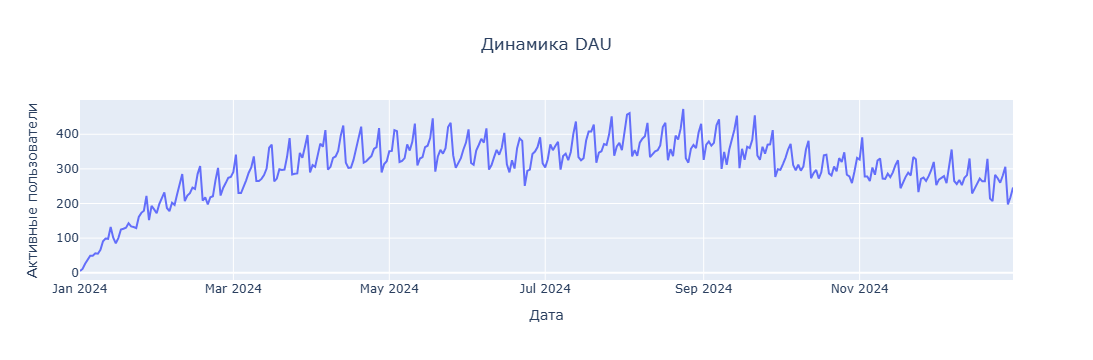

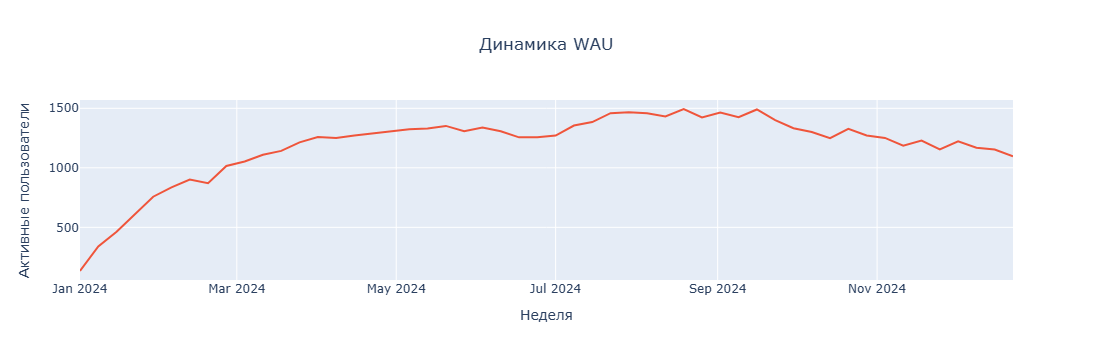

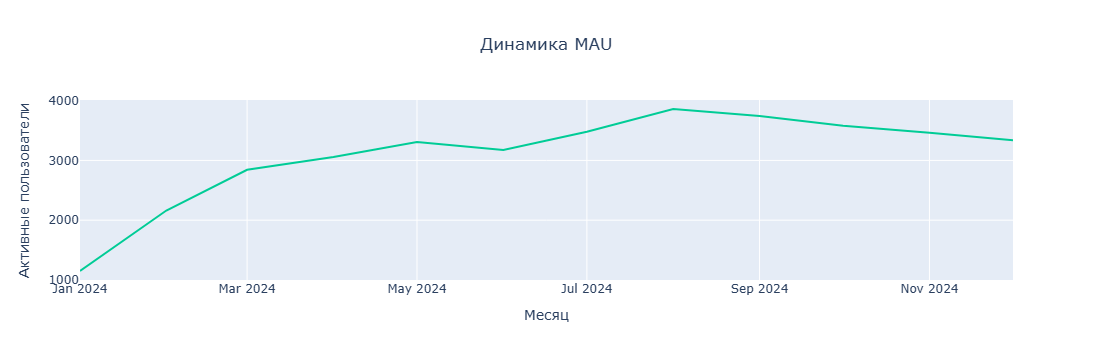

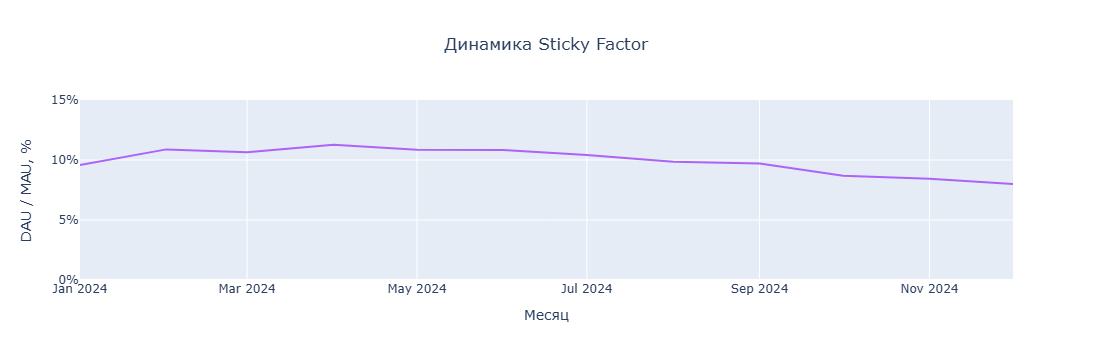

In [13]:
# Фильтруем датасет по событиям
df_events = pa_marketplace_events.query('event_type not in ("user_login", "user_logout")')
print(f"Отфильтровано {len(pa_marketplace_events) - len(df_events)} записей")

# Строим динамику DAU, WAU, MAU, Stickiness
dau = df_events.groupby('event_date', as_index=False).agg({'user_id': 'nunique', 'event_month': 'first'})
wau =  df_events.groupby('event_week', as_index=False)['user_id'].nunique()
mau = df_events.groupby('event_month', as_index=False)['user_id'].nunique()

stickiness = (dau.groupby('event_month', as_index=False)['user_id'].mean()
    .merge(mau, on='event_month', how='left')
    .rename(columns={'user_id_x': 'dau', 'user_id_y': 'mau'}))
stickiness['sf'] = stickiness['dau'] / stickiness['mau']
                        

fig1 = px.line(dau,
               x='event_date',
               y='user_id',
               title='Динамика DAU',
               labels={'event_date': 'Дата', 'user_id':'Активные пользователи'})
fig1.update_traces(line=dict(color=px.colors.qualitative.Plotly[0]))
fig1.update_layout(title_x=0.5)
fig1.show()

fig2 = px.line(wau[:-1],
               x='event_week',
               y='user_id',
               title='Динамика WAU',
               labels={'event_week': 'Неделя', 'user_id':'Активные пользователи'})
fig2.update_traces(line=dict(color=px.colors.qualitative.Plotly[1]))
fig2.update_layout(title_x=0.5)
fig2.show()

fig3 = px.line(mau,
               x='event_month',
               y='user_id',
               title='Динамика MAU',
               labels={'event_month': 'Месяц', 'user_id':'Активные пользователи'})
fig3.update_traces(line=dict(color=px.colors.qualitative.Plotly[2]))
fig3.update_layout(title_x=0.5)
fig3.show()

fig4 = px.line(stickiness,
               x='event_month',
               y='sf',
               title='Динамика Sticky Factor',
               labels={'event_month': 'Месяц', 'sf':'Sticky Factor'})
fig4.update_layout(yaxis=dict(tickformat='.0%', range=[0, 0.15], title='DAU / MAU, %'))
fig4.update_traces(line=dict(color=px.colors.qualitative.Plotly[3]))
fig4.update_layout(title_x=0.5)
fig4.show()

Активная аудитория продукта уверенно растет в первом полугодии и достигает своего пика в августе, после чего откатывается к значениям апреля-мая.

Анализ DAU выявил четкую внутринедельную сезонность: максимальная активность пользователей фиксируется по субботам, минимальная - по воскресеньям.

Stickiness (отношение среднего DAU к MAU) в первом полугодии держится на стабильном уровне, сопоставимом с бенчмарками (10-11%), но во втором полугодии снижается до 8% к декабрю. Это означает, что пользователи стали реже возвращаться в продукт, что коррелирует с общим падением вовлеченности во втором полугодии.

### Монетизация и динамика выручки
В этом разделе посмотрим, как менялись выручка, средний чек, ARPU, ARPPU и конверсия в платящих пользователей. Это поможет понять, за счёт чего падает выручка: люди стали тратить меньше или платящих стало меньше.

#### Методология расчета (выручка, средний чек, конверсия)
***Выручка***<br>
Выручка маркетплейса определяется как 5% комиссии от суммы заказа.

***ARPU и ARPPU***<br>
Метрики определяются как отношение выручки маркетплейса к:
- общему количеству активных пользователей (ARPU)
- количеству пользователей, совершивших заказ (ARPPU)

***AOV***<br>
1. При расчете AOV используется полная стоимость заказа (total_price), а не комиссия маркетплейса. Это принципиально важно, поскольку AOV отражает поведение и покупательскую способность клиентов - сколько в среднем они тратят за одну покупку, независимо от того, сколько зарабатывает на этом компания.<br>
В отличие от ARPU и ARPPU, которые считаются от выручки компании (5% комиссии), AOV показывает ценность заказа с точки зрения клиента и используется для анализа ассортимента, кросс-продаж и ценовой политики. Эта метрика критически важна для понимания, меняется ли структура потребления со временем.

2. Для расчета среднего чека используется признак агрегированного заказа `agg_order_id`.

***Конверсия***<br>
Конверсия определяется как отношение пользователей, завершивших оформление заказа, к активным пользователям.

#### Выручка и маркетинговые затраты
Сравним динамику выручки (комиссия 5%) с расходами на маркетинг по месяцам. Это покажет, окупаются ли инвестиции и есть ли связь между ростом бюджетов и выручкой.

In [14]:
# Создаем агрегированный датасет для расчета метрик монетизации
df_monetization = (pa_marketplace_orders.groupby('order_month', as_index=False)
    .agg(revenue=('commission', 'sum'),
         gmv=('total_price', 'sum'),
         cnt_paying_users=('user_id', 'nunique'),
        cnt_orders=('agg_order_id', 'nunique')))

# Добавляем информацию об активных пользователях
df_monetization = (df_monetization.merge(mau, left_on='order_month', right_on='event_month', how='left')
    .rename(columns={'user_id': 'cnt_active_users'})
    .drop('event_month', axis=1))

# Добавляем информацию о маркетинговых затратах
df_costs = pa_marketplace_campaign_costs.groupby('spend_month', as_index=False)['budget'].sum()

df_monetization = (df_monetization.merge(df_costs, left_on='order_month', right_on='spend_month', how='left').drop('spend_month', axis=1))
    
# Рассчитываем ARPU, ARPPU и AOV, количество заказов на платящего пользователя
df_monetization['arpu'] = (df_monetization['revenue'] / df_monetization['cnt_active_users']).round(2)
df_monetization['arppu'] = (df_monetization['revenue'] / df_monetization['cnt_paying_users']).round(2)
df_monetization['aov'] = (df_monetization['gmv'] / df_monetization['cnt_orders']).round(2)
df_monetization['orders_per_paying'] = df_monetization['cnt_orders'] / df_monetization['cnt_paying_users']

display(df_monetization)

,order_month,revenue,gmv,cnt_paying_users,cnt_orders,cnt_active_users,budget,arpu,arppu,aov,orders_per_paying
0,2024-01-01,648890.14,12977800.53,454,557,1149,1.177457e+06,564.74,1429.27,23299.46,1.226872
1,2024-02-01,1296557.08,25931140.19,839,1111,2162,1.061386e+06,599.70,1545.36,23340.36,1.324195
2,2024-03-01,1940749.76,38814995.89,1165,1609,2844,1.167680e+06,682.40,1665.88,24123.68,1.381116
3,2024-04-01,2142838.63,42856767.90,1324,1842,3059,1.147740e+06,700.50,1618.46,23266.43,1.391239
4,2024-05-01,2478758.41,49575162.02,1404,2021,3310,1.225322e+06,748.87,1765.50,24530.02,1.439459
5,2024-06-01,2106011.79,42120237.13,1230,1740,3174,1.130440e+06,663.52,1712.20,24207.03,1.414634
6,2024-07-01,2446535.27,48930709.06,1385,1935,3481,1.776447e+06,702.83,1766.45,25287.19,1.397112
7,2024-08-01,2465802.55,49316047.93,1385,1921,3861,1.811678e+06,638.64,1780.36,25672.07,1.387004
8,2024-09-01,1935366.81,38707333.94,1163,1604,3744,1.820719e+06,516.92,1664.12,24131.75,1.379192
9,2024-10-01,1716108.65,34322165.12,999,1411,3581,1.810803e+06,479.23,1717.83,24324.71,1.412412


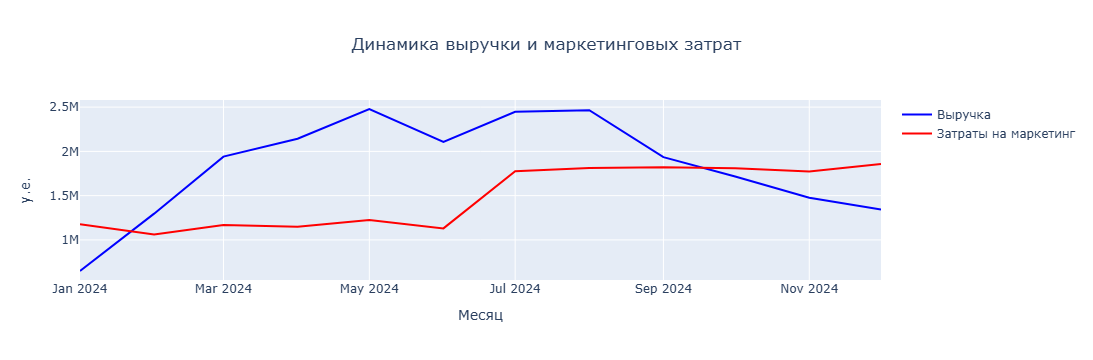

In [15]:
# Визуализируем выручку и маркетинговые затраты
fig = go.Figure()

# Выручка
fig.add_trace(go.Scatter(x=df_monetization['order_month'],
                         y=df_monetization['revenue'],
                         name='Выручка',
                         mode='lines',
                         line=dict(color='blue')))

# Маркетинговые затраты
fig.add_trace(go.Scatter(x=df_monetization['order_month'],
                         y=df_monetization['budget'],
                         name='Затраты на маркетинг',
                         mode='lines',
                         line=dict(color='red')))


fig.update_layout(title='Динамика выручки и маркетинговых затрат',
                  xaxis_title='Месяц',
                  yaxis_title='у.е.',
                  hovermode='x unified',
                  title_x=0.5)

fig.show()

Динамика выручки демонстрирует нетипичное поведение: пиковые значения выручки приходятся на май, июль и август (~2,5 млн у.е.), тогда как традиционный высокий сезон (ноябрь-декабрь) показывает минимальные результаты (1,5 млн и 1,3 млн у.е. соответственно).

Маркетинговый бюджет в первом полугодии находится в диапазоне 1-1,2 млн у.е., однако во второй половине года резко увеличивается до 1,8 млн у.е. в месяц.

При этом падение выручки в последнем квартале перестает компенсировать затраты на маркетинг. Рост инвестиций в привлечение не только не привел к увеличению выручки, но и сопровождался ее падением, что указывает на резкое снижение эффективности маркетинга во второй половине года.

#### ARPU, ARPPU и AOV
- **ARPU** — выручка на одного активного пользователя;
- **ARPPU** — выручка на одного платящего;
- **AOV** — средний чек (полная стоимость заказа).

Эти метрики помогут понять, падает выручка из-за того, что пользователи стали тратить меньше (AOV, ARPPU), или из-за того, что платящих стало меньше (ARPU).

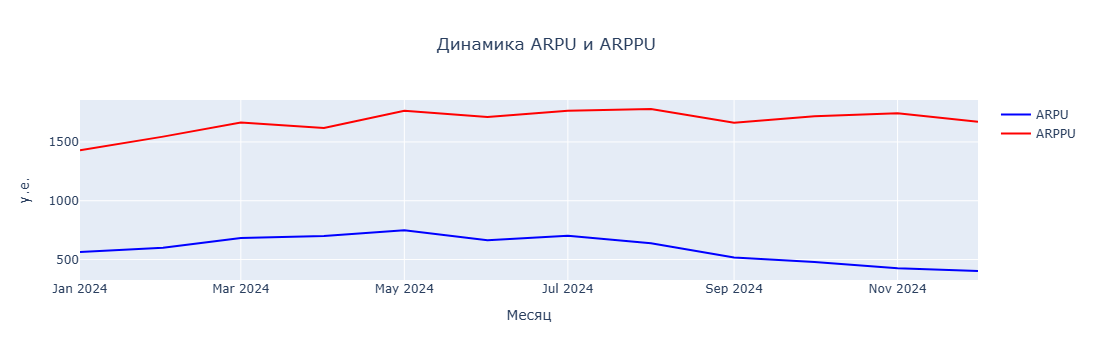

In [16]:
# Визуализируем динамику ARPU и ARPPU по месяцам
fig = go.Figure()

# ARPU
fig.add_trace(go.Scatter(x=df_monetization['order_month'],
                         y=df_monetization['arpu'],
                         name='ARPU',
                         mode='lines',
                         line=dict(color='blue')))

# ARPPU
fig.add_trace(go.Scatter(x=df_monetization['order_month'],
                         y=df_monetization['arppu'],
                         name='ARPPU',
                         mode='lines',
                         line=dict(color='red')))


fig.update_layout(title='Динамика ARPU и ARPPU',
                  xaxis_title='Месяц',
                  yaxis_title='у.е.',
                  hovermode='x unified',
                  title_x=0.5)

fig.show()

ARPU демонстрирует рост в первом полугодии, но к декабрю падает ниже значений января (с 564 у.е. до 402 у.е.), что указывает на потерю эффективности монетизации активной аудитории. ARPPU также растет в первом полугодии и снижается во втором, однако декабрьское значение стабилизируется на уровне марта (около 1670 у.е.), показывая, что качество платящей аудитории не падает ниже весенних значений. Такая динамика говорит о том, что проблемы монетизации связаны не с ухудшением платящей аудитории, а с сокращением ее доли и снижением общей активности пользователей.

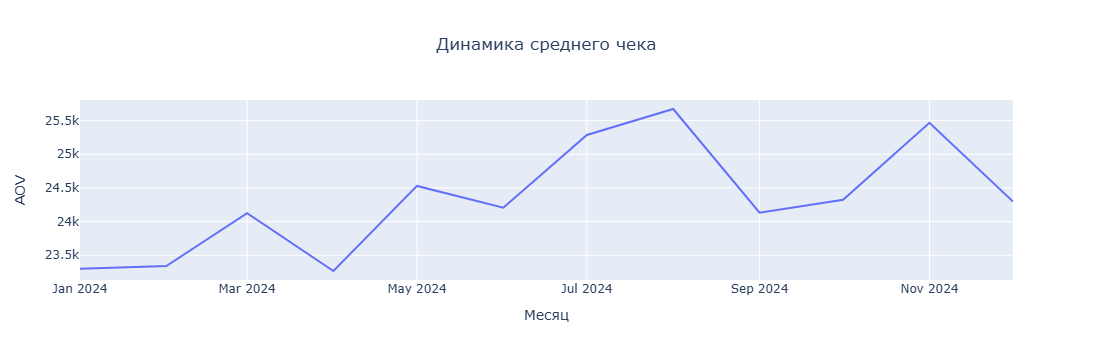

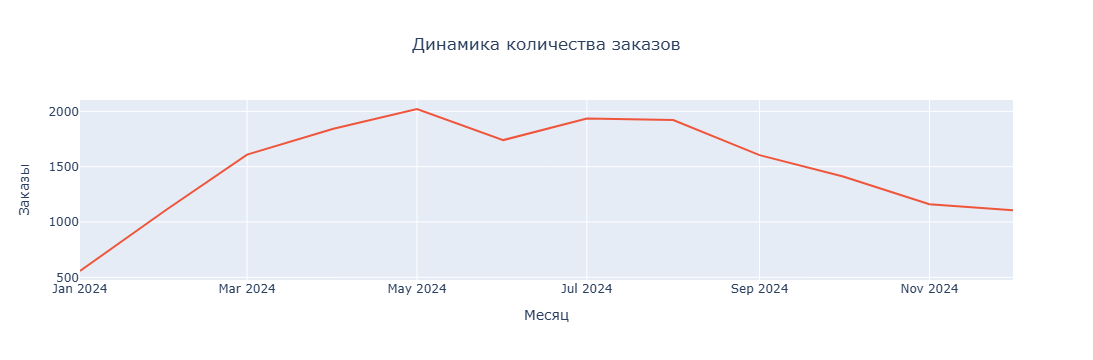

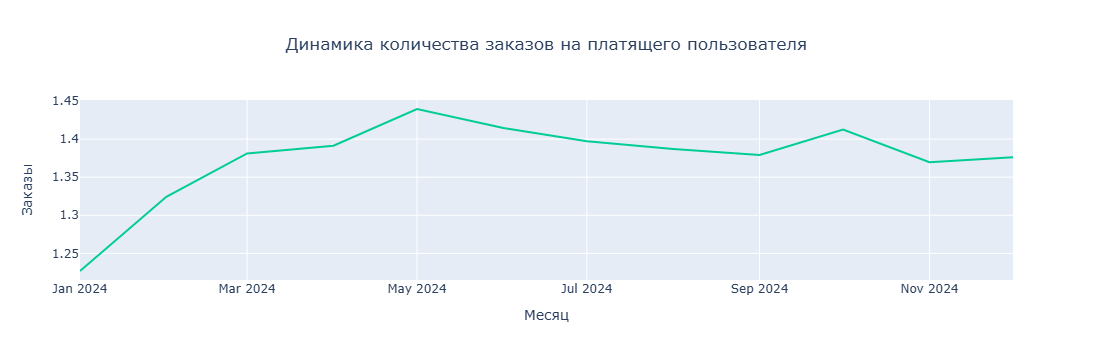

In [17]:
# Визуализируем динамику AOV по месяцам
fig = px.line(df_monetization,
               x='order_month',
               y='aov',
               title='Динамика среднего чека',
               labels={'order_month': 'Месяц', 'aov':'AOV'})
fig.update_layout(title_x=0.5)
fig.show()

# Визуализируем динамику количества заказов по месяцам
fig1 = px.line(df_monetization,
               x='order_month',
               y='cnt_orders',
               title='Динамика количества заказов',
               labels={'order_month': 'Месяц', 'cnt_orders':'Заказы'})
fig1.update_layout(title_x=0.5)
fig1.update_traces(line=dict(color=px.colors.qualitative.Plotly[1]))
fig1.show()

# Визуализируем динамику количества заказов на платящего пользователя
fig1 = px.line(df_monetization,
               x='order_month',
               y='orders_per_paying',
               title='Динамика количества заказов на платящего пользователя',
               labels={'order_month': 'Месяц', 'orders_per_paying':'Заказы'})
fig1.update_layout(title_x=0.5)
fig1.update_traces(line=dict(color=px.colors.qualitative.Plotly[2]))
fig1.show()

Средний чек (AOV) стабилен на протяжении всего года, колеблясь в узком диапазоне 23,3–25,7 тыс. у.е. без выраженной сезонности. В отличие от ARPU и общей выручки, AOV не снижается в конце года — декабрьский показатель превышает январский.

Динамика количества заказов полностью повторяет тренд выручки, что подтверждает: именно падение числа заказов, а не уменьшение среднего чека, стало основной причиной снижения выружки во втором полугодии.

Число заказов на одного платящего пользователя колеблется в узком диапазоне 1,23–1,44 на протяжении всего года и не демонстрирует драматических изменений. Даже в декабре, при минимальной выручке, этот показатель (1,38) остаётся выше январского (1,23).

#### Конверсия в платящих пользователей
Доля активных пользователей, совершивших хотя бы один заказ. Если конверсия падает, а ARPPU и AOV остаются стабильными — значит, проблема в привлечении «холодной» аудитории, а не в платёжеспособности.

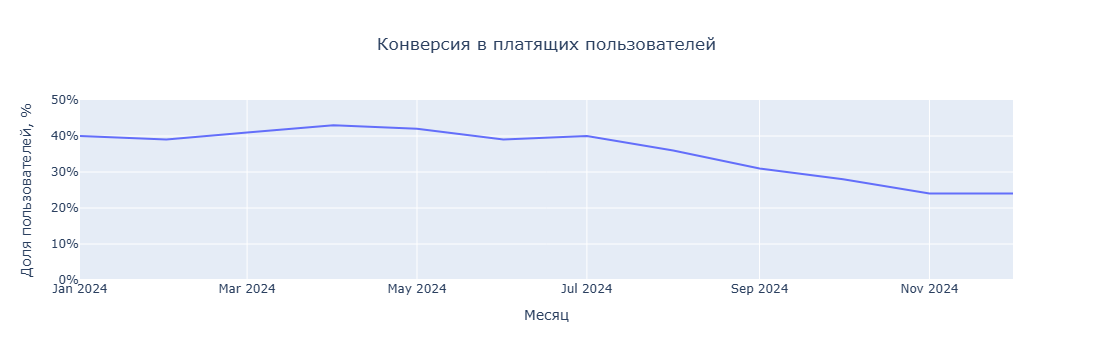

In [18]:
# Расчитываем конверсию в заказ по пользователям
df_monetization['paying_share'] = (df_monetization['cnt_paying_users'] / df_monetization['cnt_active_users']).round(2)

# Визуализируем динамику конверсии в заказ по месяцам
fig = px.line(df_monetization,
               x='order_month',
               y='paying_share',
               title='Конверсия в платящих пользователей',
               labels={'order_month': 'Месяц', 'paying_share':'Платящие пользователи'})
fig.update_layout(yaxis=dict(tickformat='.0%', range=[0, 0.5], title='Доля пользователей, %'))
fig.update_layout(title_x=0.5)
fig.show()

Конверсия в платящих пользователей демонстрирует устойчивое снижение во втором полугодии: с 40% в июле до 24% в ноябре-декабре. При этом в первом полугодии показатель держался на стабильно высоком уровне (39-43%), что указывает на эффективное вовлечение пользователей в покупки. Резкое падение доли покупателей в конце года при стабильном ARPPU подтверждает, что проблемы монетизации связаны именно с сокращением платящей аудитории, а не с ухудшением ее качества.

### Юнит-экономика и когортный анализ
Оценим, окупаются ли инвестиции в маркетинг и какие когорты пользователей приносят прибыль.

В этом разделе:
- разобьём пользователей на когорты по месяцу регистрации;
- посчитаем CAC, накопленный ARPU и ROMI для каждой когорты;
- оценим срок окупаемости когорт и построим тепловую карту.

**Ограничение:** когорты находятся в неравных временных условиях (ранние наблюдались дольше). Прямое сравнение абсолютных значений ROMI между когортами некорректно без поправки на период. Это учтено в выводах.

#### Методология расчета (CAC, ROMI, когорты)
***Когортный анализ***<br>
- В качестве когорт рассматриваются пользователи, сгруппированные по месяцу первой активности (регистрации), который определяется по полю `cohort_month` в таблице users.
- Выбор месячных когорт обусловлен доступными данными о маркетинговых затратах: таблица `pa_marketplace_campaign_costs` содержит помесячную агрегацию бюджетов по каналам привлечения.


***Базовые метрики когорты***<br>
Для каждой месячной когорты рассчитываются:
- `cnt_users` — общее количество привлеченных пользователей (размер когорты)
- `revenue` — суммарная выручка, сгенерированная когортой за весь доступный период наблюдения (2024 год)
- `budget` — маркетинговые затраты на привлечение когорты (суммируются по каналам за соответствующий месяц)


***Производные метрики***<br>
- `cumulative_arpu` = revenue / cnt_users<br>
Накопленная выручка на одного пользователя когорты за время наблюдения. Это не LTV в классическом понимании, а фактический ARPU когорты за период ее жизни в данных.
- `cac` = budget / cnt_users<br>
Стоимость привлечения одного пользователя в когорте.
- `romi` = (revenue — budget) / budget<br>
Упрощенный ROMI (возврат маркетинговых инвестиций), показывающий, сколько рублей выручки принес каждый рубль, вложенный в привлечение когорты. 

***Важное ограничение***<br>
Когорты находятся в неравных временных условиях:
- Ранние когорты (январь–апрель) наблюдались на протяжении 8–12 месяцев и имели больше возможностей для генерации выручки.
- Поздние когорты (сентябрь–декабрь) наблюдались всего 1–4 месяца.
- Прямое сравнение абсолютных значений cumulative_arpu и romi между когортами некорректно без учета разницы в периодах наблюдения. Для оценки эффективности каналов необходим анализ на фиксированных временных интервалах (например, первые 3 месяца жизни каждой когорты), однако в рамках текущего обзора мы фиксируем фактическое состояние на конец 2024 года.

#### Накопленный ARPU и CAC по когортам
Посчитаем, сколько в среднем принес пользователь каждой когорты (накопленный ARPU) и во сколько обошлось его привлечение (CAC), а также оценим динамику этих метрик.

In [19]:
# Группируем и объединяем данные
df_users = pa_marketplace_orders.groupby('user_id', as_index=False)['commission'].sum()
df_users = df_users.merge(pa_marketplace_users[['user_id', 'cohort_month']],
                          on='user_id',
                          how='right')
df_unit = df_users.groupby('cohort_month', as_index=False).agg(cnt_users=('user_id', 'count'),
                                                               revenue = ('commission', 'sum'))
df_unit = df_unit.merge(df_costs,
                        left_on='cohort_month',
                        right_on='spend_month',
                        how='outer').drop('spend_month', axis=1)

# Рассчитываем метрики юнит-экономики
df_unit['cumulative_arpu'] = (df_unit['revenue'] / df_unit['cnt_users']).round(2)
df_unit['cac'] = (df_unit['budget'] / df_unit['cnt_users']).round(2)
df_unit['romi'] = ((df_unit['revenue'] - df_unit['budget']) / df_unit['budget']).round(2)

display(df_unit)

,cohort_month,cnt_users,revenue,budget,cumulative_arpu,cac,romi
0,2024-01-01,2985,2105090.38,1.177457e+06,705.22,394.46,0.79
1,2024-02-01,2711,2052689.38,1.061386e+06,757.17,391.51,0.93
2,2024-03-01,2965,2481937.71,1.167680e+06,837.08,393.82,1.13
3,2024-04-01,2905,2456668.45,1.147740e+06,845.67,395.09,1.14
4,2024-05-01,3066,2246673.79,1.225322e+06,732.77,399.65,0.83
5,2024-06-01,2810,1891357.68,1.130440e+06,673.08,402.29,0.67
6,2024-07-01,4388,2480705.51,1.776447e+06,565.34,404.84,0.40
7,2024-08-01,4431,1883228.35,1.811678e+06,425.01,408.86,0.04
8,2024-09-01,4466,1446349.35,1.820719e+06,323.86,407.68,-0.21
9,2024-10-01,4440,1107371.43,1.810803e+06,249.41,407.84,-0.39


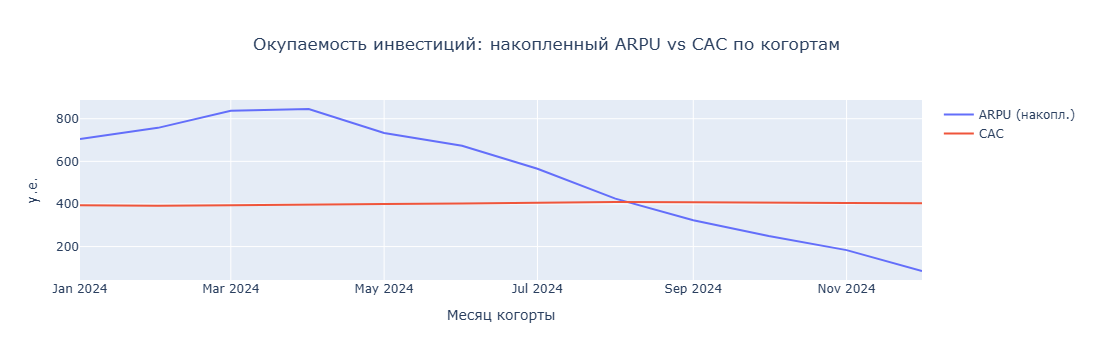

In [20]:
# Визуализируем cumulative ARPU и CAC
fig = go.Figure()

# ARPU
fig.add_trace(go.Scatter(x=df_unit['cohort_month'],
                         y=df_unit['cumulative_arpu'],
                         name='ARPU (накопл.)',
                         line=dict(color=px.colors.qualitative.Plotly[0]),
                         mode='lines'))

# CAC
fig.add_trace(go.Scatter(x=df_unit['cohort_month'],
                         y=df_unit['cac'],
                         name='CAC',
                         line=dict(color=px.colors.qualitative.Plotly[1]),
                         mode='lines'))


fig.update_layout(title='Окупаемость инвестиций: накопленный ARPU vs CAC по когортам',
                  xaxis_title='Месяц когорты',
                  yaxis_title='у.е.',
                  hovermode='x unified',
                  title_x=0.5)

fig.show()

Накопленный ARPU демонстрирует нелинейную динамику: максимальные значения достигаются в мартовской и апрельской когортах (837 и 845 у.е.), которые при более коротком периоде наблюдения обогнали январскую и февральскую когорты (705 и 757 у.е.). Это указывает на рост качества привлечения или повышение эффективности монетизации во втором квартале. В более поздних когортах ARPU закономерно снижается из-за уменьшения периода наблюдения.

CAC при этом остается стабильным на уровне 390–410 у.е. на протяжении всего года, что свидетельствует о равномерности маркетинговой стратегии.

### Окупаемость когорт и каналов (ROMI)
Проанализируем окупаемость маркетинговых инвестиций в зависмости от месячной когорты пользователей.

#### Окупаемость когорт

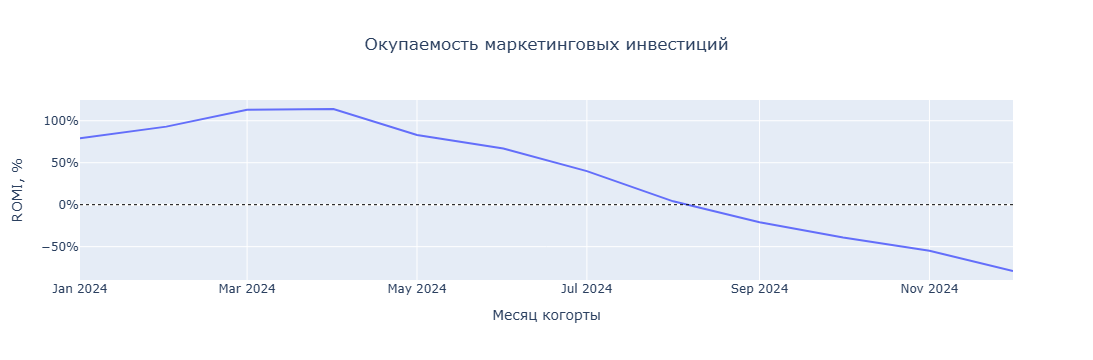

In [21]:
# Визуализируем ROMI
fig = px.line(df_unit,
               x='cohort_month',
               y='romi',
               title='Окупаемость маркетинговых инвестиций',
               labels={'cohort_month': 'Месяц когорты', 'romi':'ROMI'})

fig.update_layout(yaxis=dict(tickformat='.0%', title='ROMI, %'))
fig.update_layout(title_x=0.5)

fig.add_hline(y=0, line=dict(color='black', width=1, dash='dot'))

fig.show()

Ранние когорты успешно окупаются (ROMI до 114%), тогда как поздние уходят в минус. Причина может быть как в недостаточном периоде наблюдения (у поздних когорт было меньше времени, чтобы окупиться), так и в реальном падении качества когорт.

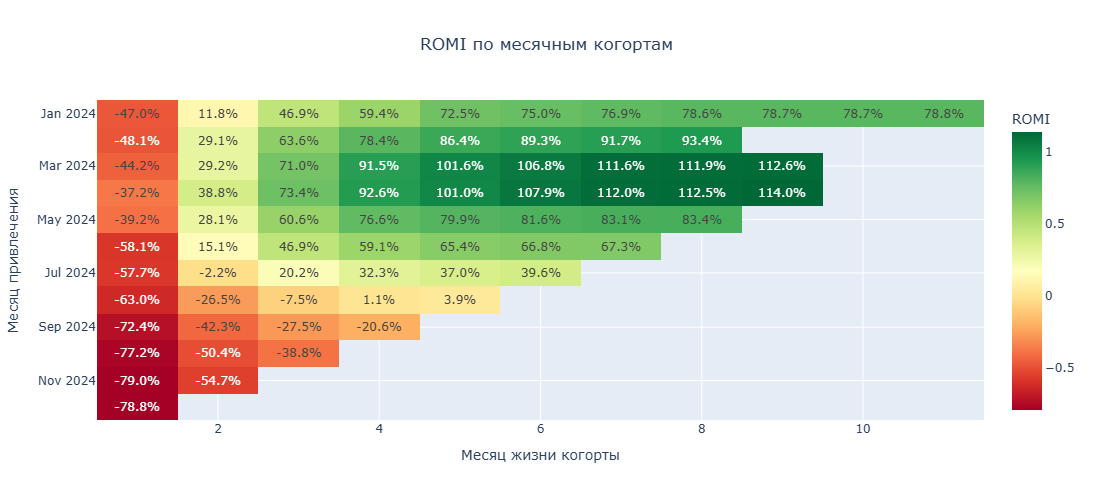

In [22]:
# Рассчитываем кумулятивную выручку по месяцам для месячных когорт
df = pa_marketplace_orders[['user_id', 'order_month', 'commission']].merge(pa_marketplace_users[['user_id', 'cohort_month']],
                                                              on='user_id',
                                                              how='inner')

df_cohort_revenue = df.groupby(['cohort_month', 'order_month'], as_index=False)['commission'].sum().rename(columns={'commission': 'revenue'})

df_cohort_revenue['cum_revenue'] = df_cohort_revenue.groupby('cohort_month')['revenue'].cumsum()

# Определяем порядковый номер месяцев для каждой когорты
df_cohort_revenue['n_month'] = df_cohort_revenue['order_month'].dt.month - df_cohort_revenue['cohort_month'].dt.month + 1

# Добавляем данные по маркетинговым затартам, определяем ROMI по месяцам
df_cohort_revenue = df_cohort_revenue.merge(df_costs, left_on='cohort_month', right_on='spend_month', how='left')
df_cohort_revenue['cum_romi'] = (df_cohort_revenue['cum_revenue'] - df_cohort_revenue['budget'])  / df_cohort_revenue['budget']

# Пивотируем данные
pivot_romi = df_cohort_revenue.pivot(index='cohort_month', columns='n_month', values='cum_romi')

# Визуализируем тепловую карту ROMI
fig = px.imshow(
    pivot_romi,
    title='ROMI по месячным когортам',
    labels=dict(x='Месяц жизни когорты',
                y='Месяц привлечения',
                color='ROMI'),
    color_continuous_scale='RdYlGn',
    text_auto='.1%',
    aspect='auto')

          
fig.update_layout(title_x=0.5, height=500)
fig.show()

Когорты первого полугодия стабильно окупались на 2-й месяц жизни. Начиная с июля срок окупаемости увеличивается до 3–4 месяцев, а сентябрьские–декабрьские когорты так и не выходят в плюс за доступный период наблюдения.

#### Окупаемость каналов привлечения

##### Выручка и затраты по каналам

Проведем анализ окупаемости маркетинговых инвестиций в разрезе каналов привлечения. Оценим ROMI, структуру затрат и качество трафика каждого канала, чтобы выявить эффективные источники аудитории и проблемные зоны для перераспределения бюджета.

In [23]:
# Группируем и объединяем данные
df_users_channel = pa_marketplace_orders.groupby('user_id', as_index=False)['commission'].sum()
df_users_channel = df_users_channel.merge(pa_marketplace_users[['user_id', 'cohort_month', 'acq_channel']],
                          on='user_id',
                          how='outer')


df_users_channel = df_users_channel.dropna(subset=['cohort_month', 'acq_channel'])


df_unit_channel = df_users_channel.groupby(['cohort_month', 'acq_channel'])[['user_id', 'commission']].agg(
    cnt_users=('user_id', 'count'),
    revenue=('commission', 'sum')
).reset_index()

df_unit_channel = df_unit_channel.merge(pa_marketplace_campaign_costs,
                        left_on=['cohort_month', 'acq_channel'],
                        right_on=['spend_month', 'acq_channel'],
                        how='outer')

# Рассчитываем метрики юнит-экономики
df_unit_channel['cumulative_arpu'] = (df_unit_channel['revenue'] / df_unit_channel['cnt_users']).round(2)
df_unit_channel['cac'] = (df_unit_channel['budget'] / df_unit_channel['cnt_users']).round(2)
df_unit_channel['romi'] = ((df_unit_channel['revenue'] - df_unit_channel['budget']) / df_unit_channel['budget']).round(2)

display(df_unit_channel.head())

,cohort_month,acq_channel,cnt_users,revenue,spend_month,budget,cumulative_arpu,cac,romi
0,2024-01-01,Affiliate,575.0,562577.84,2024-01-01,179343.38750,978.40,311.90,2.14
1,NaT,Direct,NaN,NaN,2024-01-01,11890.80375,NaN,NaN,NaN
2,2024-01-01,Email Marketing,175.0,53929.98,2024-01-01,44263.61250,308.17,252.93,0.22
3,2024-01-01,Google Ads,1119.0,1011118.84,2024-01-01,559875.81250,903.59,500.34,0.81
4,2024-01-01,SEO,316.0,210071.36,2024-01-01,59683.72500,664.78,188.87,2.52


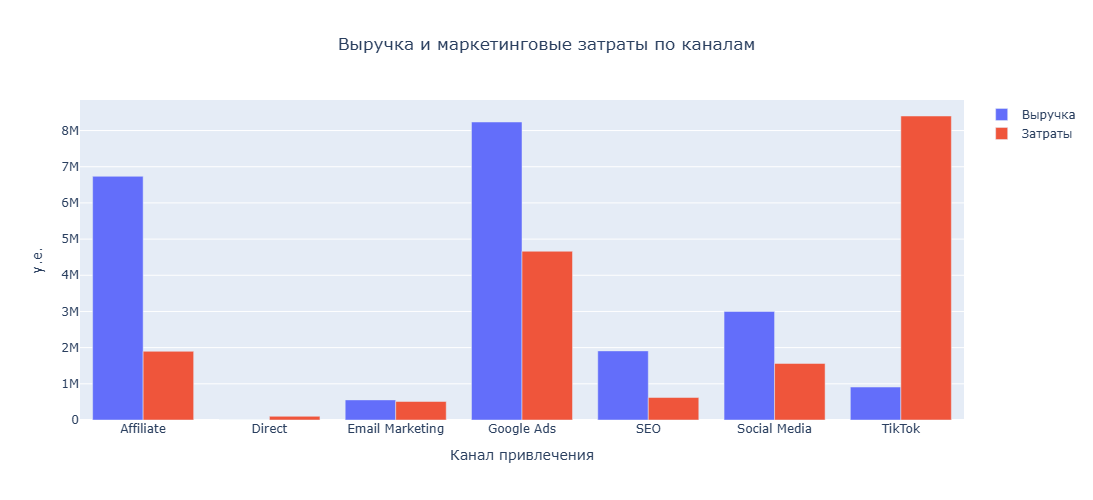

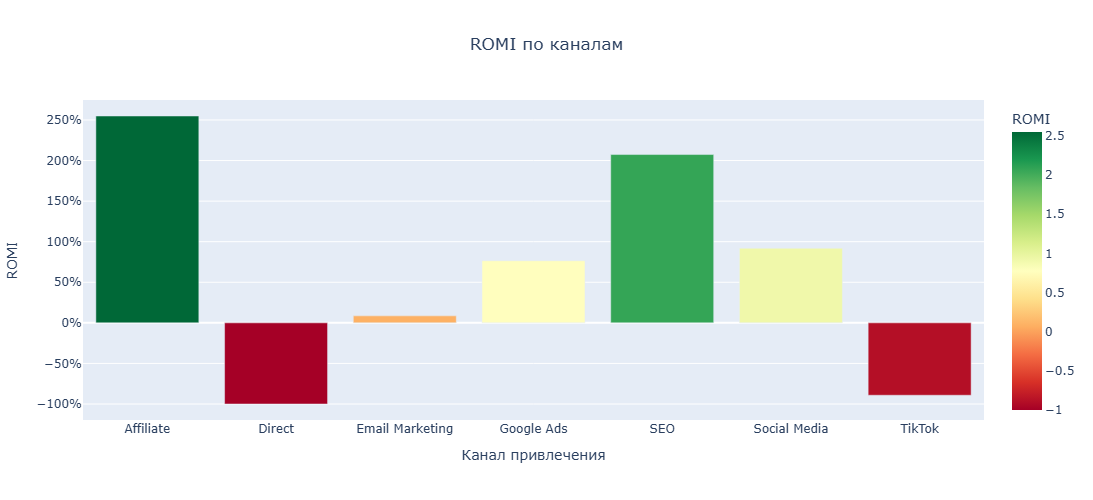

In [24]:
# Визуализируем выручку и затраты на маркетинг
df_channel = df_unit_channel.groupby('acq_channel', as_index=False).agg({'revenue': 'sum', 'budget': 'sum'})
df_channel['romi'] = ((df_channel['revenue'] - df_channel['budget']) / df_channel['budget']).round(3)

fig = go.Figure(data=[go.Bar(name='Выручка', x=df_channel['acq_channel'], y=df_channel['revenue'], marker_color=px.colors.qualitative.Plotly[0]),
                      go.Bar(name='Затраты', x=df_channel['acq_channel'], y=df_channel['budget'], marker_color=px.colors.qualitative.Plotly[1])])

fig.update_layout(title='Выручка и маркетинговые затраты по каналам',
                  xaxis_title='Канал привлечения',
                  yaxis_title='у.е.',
                  barmode='group',
                  title_x=0.5,
                  height=500)

fig.show()

fig1 = px.bar(df_channel,
             x='acq_channel',
             y='romi',
             color='romi',
             color_continuous_scale='RdYlGn',
             title='ROMI по каналам',
             labels={'acq_channel': 'Канал привлечения', 'romi': 'ROMI'},
              hover_data={'romi': ':.1%'})
fig1.update_layout(title_x=0.5, height=500, yaxis=dict(tickformat='.0%'))
fig1.show()

Лидеры по окупаемости:
- Affiliate, Google Ads, Social Media и SEO показывают уверенное превышение выручки над затратами — это основные драйверы монетизации.
- Google Ads — абсолютный лидер по объёму выручки (8,2 млн у.е.) при умеренных затратах.

Проблемные зоны:
- TikTok — критически убыточен: при затратах 8,4 млн у.е. выручка составила всего 0,9 млн, что указывает на неэффективность инвестиций в этот канал.
- Direct — при затратах 102 тыс. у.е. не привёл ни одного отслеженного пользователя (нулевая выручка). Требуется аудит настроек отслеживания либо пересмотр стратегии.
- Email Marketing — работает на грани окупаемости (выручка 556 тыс. у.е, затраты 512 тыс. у.е.), потенциал роста требует дополнительного анализа.

#### Динамика ROMI по каналам и когортам
Посмотрим, как менялась окупаемость каналов во времени — по месяцам привлечения (когортам). Это поможет понять, ухудшается ли эффективность каналов со временем или проблема носит общий характер.

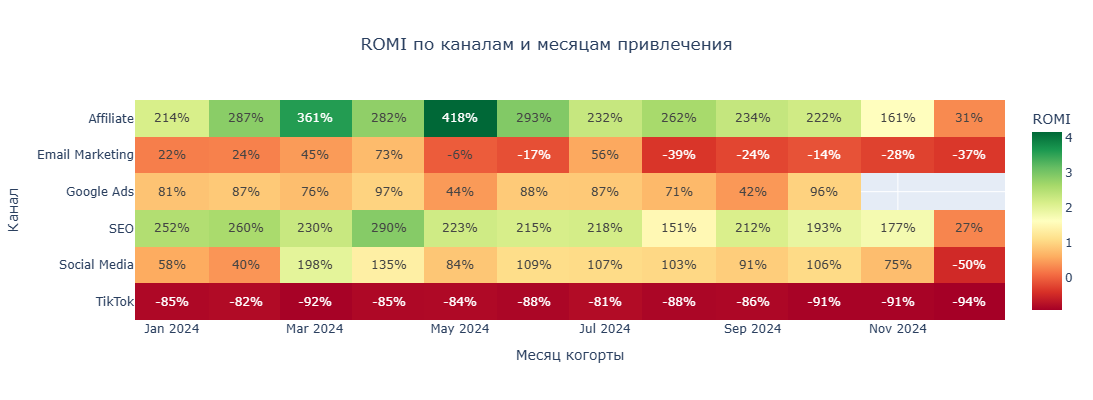

In [25]:
# Визуализируем ROMI по каналам в разрезе когорт
pivot_romi_channel = df_unit_channel.pivot_table(index='acq_channel', columns='cohort_month', values='romi', aggfunc='sum')

fig = px.imshow(pivot_romi_channel,
                title='ROMI по каналам и месяцам привлечения',
                labels=dict(x='Месяц жизни когорты',
                            y='Канал привлечения',
                            color='ROMI'),
                color_continuous_scale='RdYlGn',
                text_auto='.0%',
                aspect='auto')
          
fig.update_layout(title_x=0.5, height=400, xaxis_title='Месяц когорты', yaxis_title='Канал')
fig.show()

В динамике каналов прослеживается общий тренд: эффективность большинства из них снижается к концу года, что совпадает с падением качества трафика и ростом конкуренции в высокий сезон.
- Аффилиаты и Social Media стабильно эффективны на протяжении всего года — это основа, на которую можно опираться при планировании бюджетов.
- Google Ads демонстрировал высокие показатели ROMI в течение января-октября, но затем инвестиции в канал были остановлены.
- Email-маркетинг показал всплески весной и в июле, но во втором полугодии ушёл в минус — стоит изучить, какие именно рассылки сработали, и попытаться масштабировать успешные механики.
- TikTok стабильно убыточен весь год и требует либо полной остановки инвестиций, либо кардинального пересмотра стратегии.
- SEO до осени держался на высоком уровне, но к декабрю заметно просел — возможно, сказалась сезонность или изменение алгоритмов.

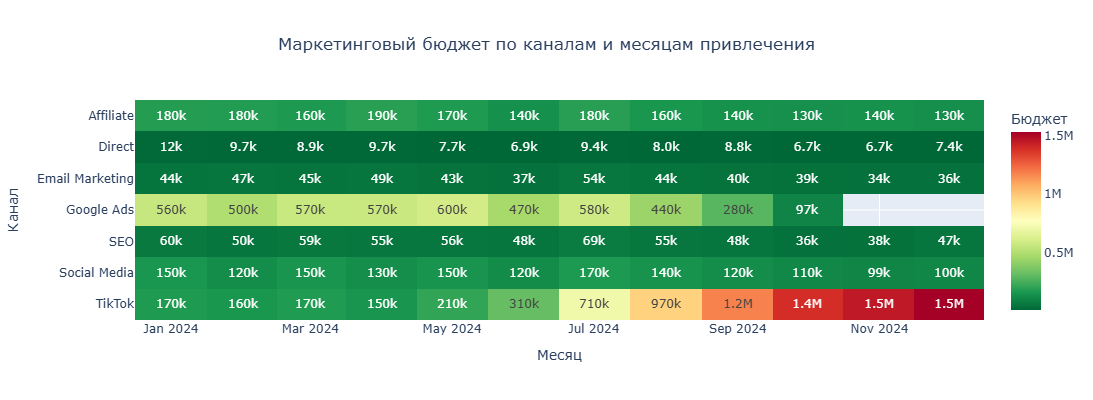

In [26]:
# Визуализируем затраты на маркетинг в разрезе каналов
pivot_budget_channel = df_unit_channel.pivot_table(index='acq_channel', columns='spend_month', values='budget', aggfunc='sum')

fig = px.imshow(pivot_budget_channel,
                title='Маркетинговый бюджет по каналам и месяцам привлечения',
                labels=dict(x='Месяц жизни когорты',
                            y='Канал привлечения',
                            color='Бюджет'),
                color_continuous_scale='RdYlGn_r',
                text_auto='.2s',
                aspect='auto')

fig.update_layout(title_x=0.5, height=400, xaxis_title='Месяц', yaxis_title='Канал')
fig.show()

Бюджет на привлечение распределён неравномерно как по каналам, так и по месяцам. Основной объём инвестиций приходится на Google Ads и TikTok, при этом их динамика противоположна: если Google Ads активен в первом полугодии и сворачивается к концу года, то TikTok, напротив, кратно наращивает бюджеты с июля, достигая максимума в декабре (1.53 млн у.е.).

Affiliate и Social Media получают стабильное, но умеренное финансирование на протяжении всего года (~150–180 тыс. у.е. ежемесячно), формируя надёжную опорную базу.

Direct и Email Marketing финансируются минимально (до 50 тыс. у.е.) и не демонстрируют выраженной сезонности.

Провал в Google Ads в конце года совпадает по времени с резким ростом вложений в TikTok и падением качества аудитории — гипотеза о перетоке бюджетов в неэффективный канал требует проверки.

### Пользовательские сегменты

Проведем сегментацию пользовательской базы для выявления групп с разным покупательским поведением. Оценим распределение аудитории по полу, возрасту, регионам и фактической покупательской активности, чтобы определить ключевые сегменты для удержания и монетизации.

#### Демография (возраст, пол, регион)

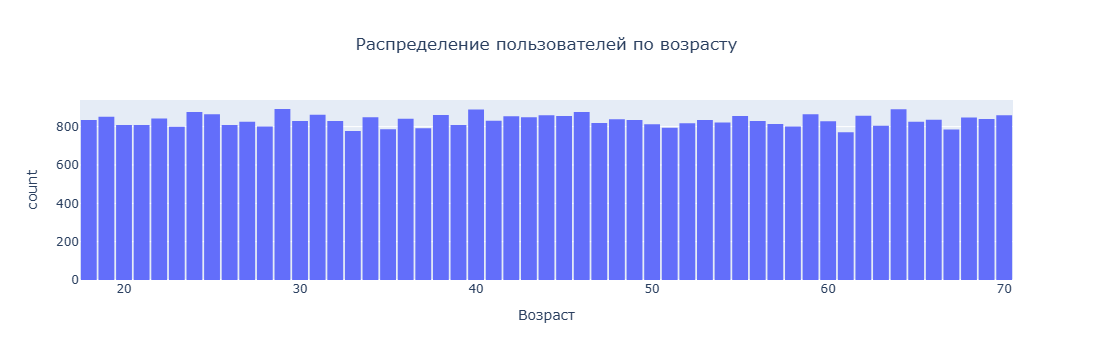

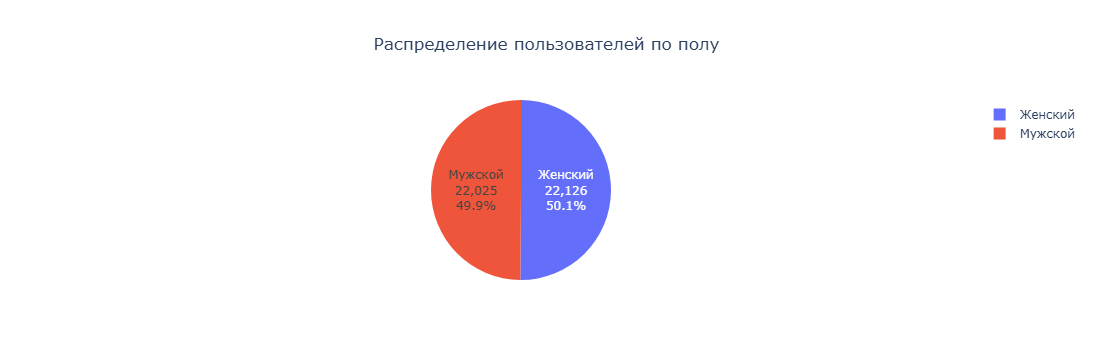

In [27]:
# Сегментируем пользователей по возрасту и полу
fig = px.histogram(pa_marketplace_users,
                   x='age',
                   nbins=70,
                   title='Распределение пользователей по возрасту',
                   labels={'age': 'Возраст', 'count': 'Количество'})
fig.update_layout(title_x=0.5, bargap=0.1)
fig.show()

gender_counts = pa_marketplace_users['gender'].value_counts().reset_index()
gender_counts['gender'] = gender_counts['gender'].map({'F': 'Женский', 'M': 'Мужской'})
fig1 = px.pie(gender_counts,
             values='count',
             names='gender',
             title='Распределение пользователей по полу',
             labels={'gender': 'Пользователи', 'gender': 'Пол'})
fig1.update_layout(title_x=0.5, showlegend=True)
fig1.update_traces(textinfo='percent+label+value')
fig1.show()

Аудитория равномерно распределена по возрасту и полу, наблюдаются лишь незначительные колебания, не влияющие на общую картину.

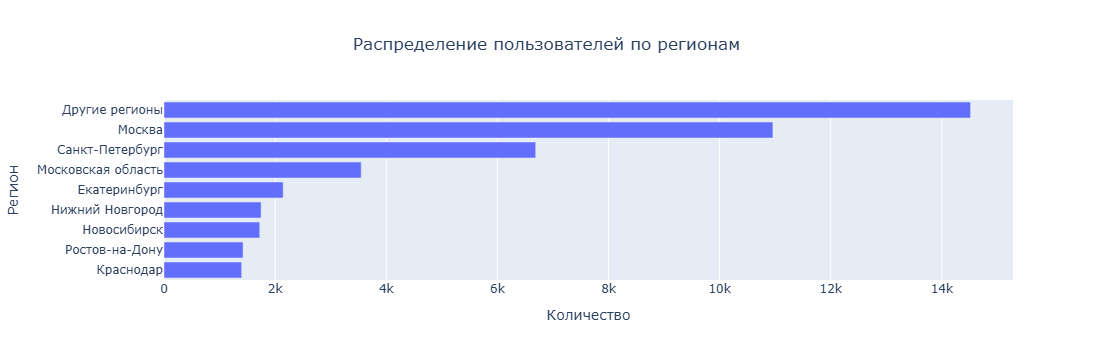

In [28]:
# Сегменитируем пользователей по регионам
region_counts = pa_marketplace_users['region'].value_counts().reset_index()

fig = px.bar(region_counts,
             x='count',
             y='region',
             orientation='h',
             title='Распределение пользователей по регионам',
             labels={'region': 'Регион', 'count': 'Количество'})
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'total ascending'})
fig.show()

Пользователи сконцентрированы в столичном регионе и крупных городах-миллионниках, при этом "Другие регионы" формируют крупнейшую, но слабоструктурированную группу.
- Аудитория сконцентрирована в Москве, области и Санкт-Петербурге.
- Ядро региональной аудитории за пределами столиц — Екатеринбург, Нижний Новгород и Новосибирск.
- Ростов-на-Дону и Краснодар замыкают список, заметно уступая лидерам.

#### Покупательская активность (частота покупок)

In [29]:
# Оцениваем распределение количества заказов на пользователя в зависимости от buyer_segment
users_with_orders = (pa_marketplace_users[['user_id', 'buyer_segment']]
    .merge(pa_marketplace_orders[['user_id', 'order_id', 'agg_order_id']],
           on='user_id',
           how='left'))

user_metrics  = (users_with_orders.groupby(['user_id', 'buyer_segment'], as_index=False, observed=True)
    .agg({'order_id': 'nunique', 'agg_order_id': 'nunique'}))

segment_stats = (user_metrics.groupby('buyer_segment')
    .agg(min_orders=('agg_order_id', 'min'),
         avg_orders=('agg_order_id', 'mean'),
         max_orders=('agg_order_id', 'max'))).round(2)

display(segment_stats)

,min_orders,avg_orders,max_orders
buyer_segment,,,
medium,0,0.34,9
one_time,0,0.04,1
rare,0,0.09,4
regular,0,1.35,25


Для исследования покупательской активности пользователей данная сегментация (`buyer_segment`) неприменима.
Анализ показал, что выделенные группы не отражают реальной частоты покупок: среднее число заказов в сегменте one_time (0,04) ниже, чем в rare (0,09), а medium (0,34) практически не отличается от неактивных пользователей.

Кроме того, в сегментации отсутствует отдельная категория для пользователей без покупок — нулевые значения «размазаны» по другим группам, что искажает их характеристики.

Поскольку логика выделения сегментов неинтерпретируема и не соответствует поведенческим паттернам, использование этой группировки в дальнейшем анализе некорректно. Для сегментации пользователей по покупательской активности требуется построение прозрачной метрики (например, среднее число заказов в месяц с поправкой на время жизни).

In [30]:
# Смотрим статистику пользователей по покупкам
user_purchase_stats = pa_marketplace_orders.groupby('user_id', as_index=False)['agg_order_id'].nunique()

user_purchase_stats = (user_purchase_stats.merge(pa_marketplace_users[['user_id', 'cohort_month']],
                                                 on='user_id',
                                                 how='right')
    .fillna(0)
    .rename(columns={'agg_order_id': 'cnt_orders'}))

user_purchase_stats['month_activity'] = 13 - user_purchase_stats['cohort_month'].dt.month

user_purchase_stats['orders_per_month'] = user_purchase_stats['cnt_orders'] / user_purchase_stats['month_activity']

user_purchase_stats_filter = user_purchase_stats.query('orders_per_month > 0')

display(user_purchase_stats_filter['orders_per_month'].describe())

count    8654.000000
mean        0.354858
std         0.378404
min         0.083333
25%         0.125000
50%         0.200000
75%         0.428571
max         4.000000
Name: orders_per_month, dtype: float64

На основании распределения усредненной активности пользователей предлагается выделить следующие сегменты

| Сегмент           | Границы (заказов в месяц) | Частота покупок          | Доля аудитории<br>(среди платящих) |
|-------------------|---------------------------|---------------------------|----------------|
| **Без покупок**   | 0                         | не покупали               | —              |
| **Очень редкие**  | < 0.15                    | реже 1 раза в 6 месяцев   | ~25%           |
| **Редкие**        | 0.15 – 0.25               | 1 раз в 4–6 месяцев       | ~25%           |
| **Средние**       | 0.25 – 0.5                | 1 раз в 2–4 месяца        | ~25%           |
| **Частые**        | > 0.5             | Чаще, чем раз в 2 месяца  | ~25%           |



In [31]:
# Определяем границы категорий
bins = [0, 0.01, 0.15, 0.25, 0.5, float('inf')]
labels = ['non_buyer', 'very_rare', 'rare', 'medium', 'frequent']

user_purchase_stats['freq_segment'] = pd.cut(user_purchase_stats['orders_per_month'],
                                             bins=bins,
                                             labels=labels,
                                             right=False,
                                             include_lowest=True)

display(user_purchase_stats.head())

,user_id,cnt_orders,cohort_month,month_activity,orders_per_month,freq_segment
0,1,0.0,2024-01-01,12,0.000000,non_buyer
1,2,0.0,2024-01-01,12,0.000000,non_buyer
2,3,2.0,2024-01-01,12,0.166667,rare
3,4,0.0,2024-01-01,12,0.000000,non_buyer
4,5,9.0,2024-01-01,12,0.750000,frequent


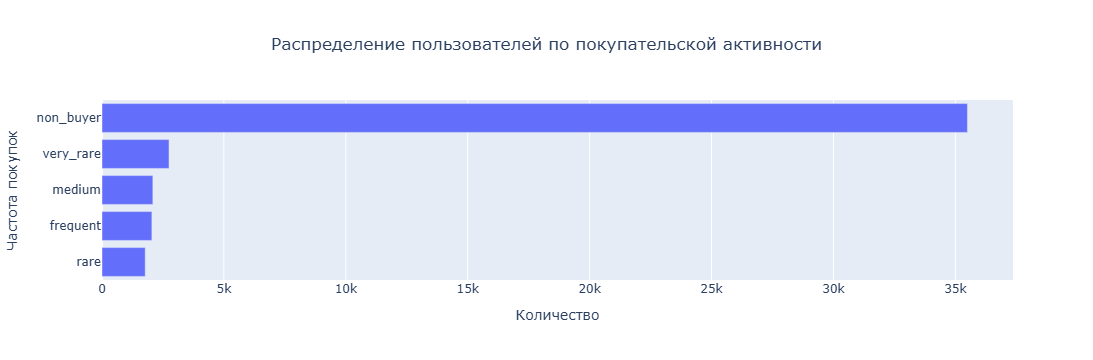

In [32]:
# Визуализируем сегментацию пользователей по покупательской активности
freq_counts = user_purchase_stats['freq_segment'].value_counts().reset_index()
freq_counts['share'] = (freq_counts['count'] / freq_counts['count'].sum()).round(3)

fig = px.bar(freq_counts,
             x='count',
             y='freq_segment',
             orientation='h',
             title='Распределение пользователей по покупательской активности',
             labels={'freq_segment': 'Частота покупок', 'count': 'Количество', 'share': 'Доля'},
             hover_data={'share': ':.1%'})
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'total ascending'})
fig.show()

Основная масса аудитории (около 80%) — никогда не покупали. Это зона роста для конверсии из регистрации в первую покупку.

Среди покупателей:
- Редкие (very_rare + rare) — чуть больше 10% аудитории
- Активные (medium + frequent) — около 9%, именно они формируют ядро постоянных покупателей и основную выручку

Поскольку наиболее заметна разница между признаками "платящий"/"неплатящий", исследуем их более детально.

#### Платящие vs неплатящие по когортам и сегментам

In [33]:
# Создаем датасет с признаком платящего пользователя
payers = pa_marketplace_orders['user_id'].unique()
user_base = pa_marketplace_users[['user_id', 'cohort_month', 'acq_channel', 'region', 'gender', 'age']].copy()
user_base['is_payer'] = user_base['user_id'].isin(payers)
user_base['status'] = user_base['is_payer'].replace({True: 'платящие', False: 'неплатящие'})
display(user_base.head())

,user_id,cohort_month,acq_channel,region,gender,age,is_payer,status
0,1,2024-01-01,Google Ads,Москва,M,35,False,неплатящие
1,2,2024-01-01,Email Marketing,Москва,M,53,False,неплатящие
2,3,2024-01-01,Google Ads,Санкт-Петербург,F,66,True,платящие
3,4,2024-01-01,Affiliate,Краснодар,M,58,False,неплатящие
4,5,2024-01-01,Google Ads,Другие регионы,F,58,True,платящие


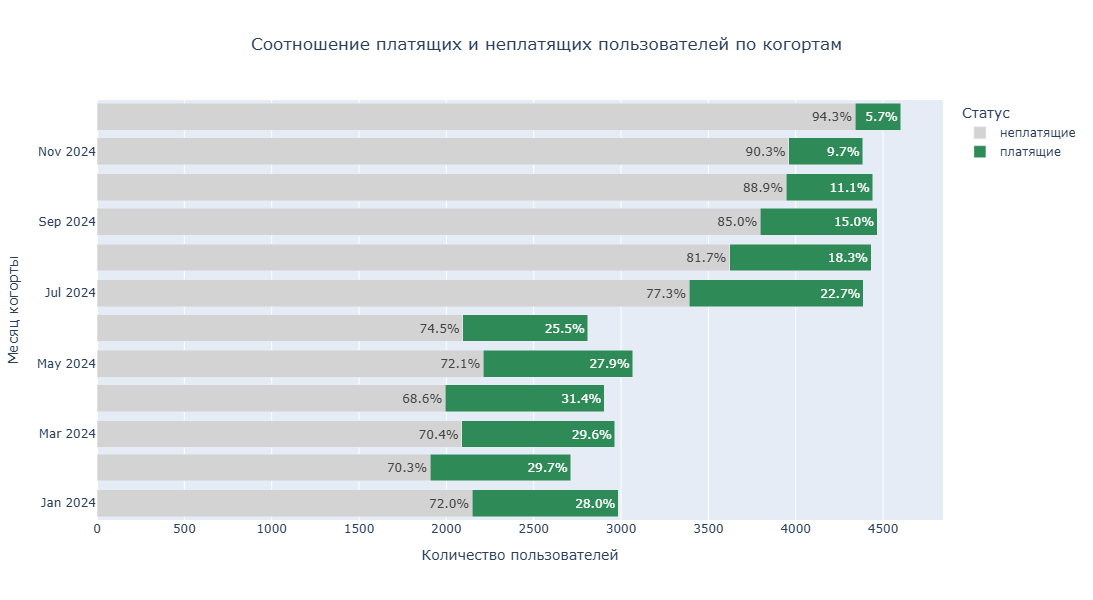

In [34]:
# Сегментируем когорты по признаку платящего пользователя
cohort_payers = user_base.groupby(['cohort_month', 'status'], as_index=False)['user_id'].count().rename(columns={'user_id': 'count'})
cohort_payers['share'] = cohort_payers.groupby('cohort_month')['count'].transform(lambda x: (x / x.sum()).round(3))

fig = px.bar(cohort_payers,
             y='cohort_month',
             x='count',
             color='status',
             color_discrete_map={'платящие': '#2E8B57', 'неплатящие': '#D3D3D3'},
             title='Соотношение платящих и неплатящих пользователей по когортам',
             labels={'cohort_month': 'Месяц когорты', 'count': 'Количество пользователей', 'status': 'Статус', 'share': 'Доля'},
             barmode='stack',
             orientation='h',
             text='share',
             hover_data={'share': ':.1%'})

fig.update_traces(texttemplate='%{text:.1%}', textposition='inside')
fig.update_layout(title_x=0.5, height=600, xaxis_title='Количество пользователей')

fig.show()

Рост маркетингового бюджета во втором полугодии привёл к увеличению аудитории, но сопровождался резким падением её качества. Доля платящих пользователей неуклонно снижалась от когорты к когорте — с почти трети в первом полугодии до единичных процентов в декабре.

Абсолютное число платящих также сократилось: при росте размера когорт в полтора раза мы получаем в разы меньше покупателей, чем в начале года.

Маркетинговые вложения перестали окупаться: деньги потрачены, аудитория выросла, но платящих стало меньше.

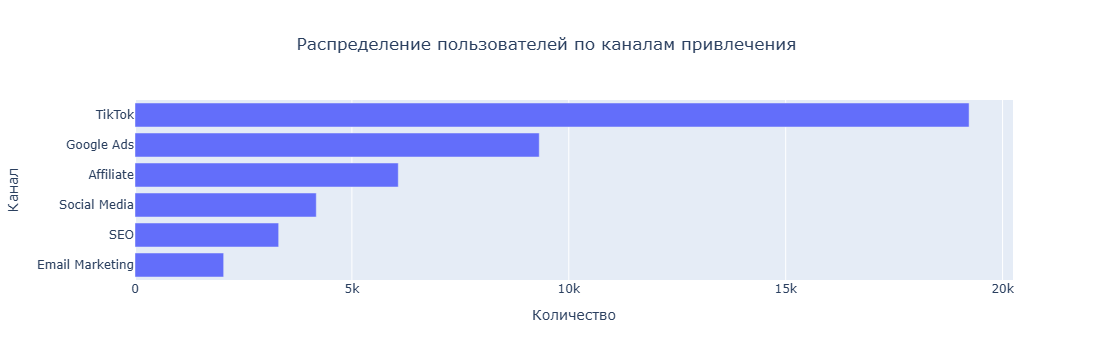

In [35]:
# Визуализируем сегментацию пользователей по каналам привлечения
channel_counts = pa_marketplace_users['acq_channel'].value_counts().reset_index()
channel_counts['share'] = (channel_counts['count'] / channel_counts['count'].sum()).round(3)

fig = px.bar(channel_counts,
             x='count',
             y='acq_channel',
             orientation='h',
             title='Распределение пользователей по каналам привлечения',
             labels={'count': 'Количество', 'acq_channel': 'Канал', 'share': 'Доля'},
             hover_data={'share': ':.1%'})
fig.update_layout(title_x=0.5, yaxis={'categoryorder':'total ascending'})
fig.show()

Основной объём аудитории формируют три канала: TikTok привлекает почти половину всех пользователей (44%), Google Ads — ещё пятую часть (21%), а Affiliate — около 14%. В совокупности на них приходится почти 80% всей аудитории.

Social Media, SEO и Email Marketing играют вспомогательную роль, обеспечивая оставшиеся 20% трафика. При этом Email Marketing, несмотря на минимальную долю (менее 5%), ранее показывал неплохую конверсию, что делает его недооценённым каналом.

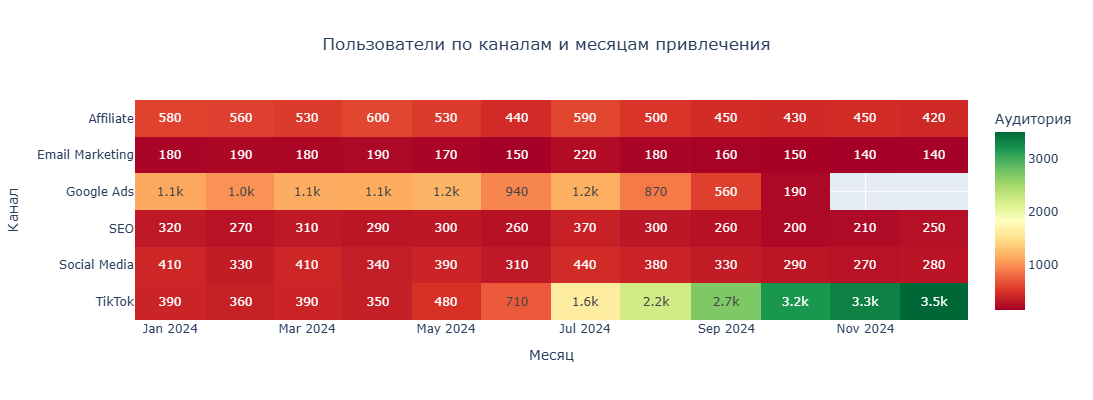

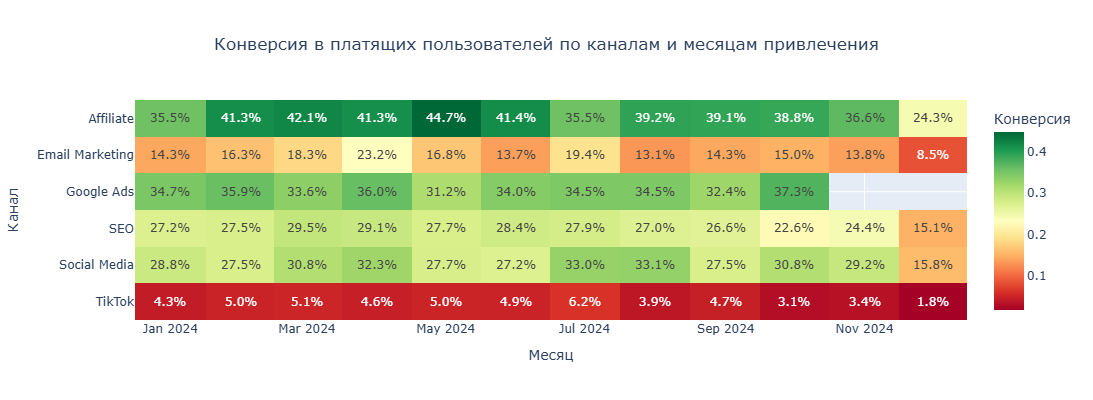

In [36]:
# Визуализируем пользователей по каналам привлечения и когортам
users_channels = pa_marketplace_users.groupby(['acq_channel', 'cohort_month'], as_index=False, observed=True)['user_id'].count()
pivot_users_channels = users_channels.pivot(index='acq_channel', columns='cohort_month', values='user_id')

fig = px.imshow(pivot_users_channels,
                title='Пользователи по каналам и месяцам привлечения',
                labels=dict(x='Месяц когорты',
                            y='Канал привлечения',
                            color='Аудитория'),
                color_continuous_scale='RdYlGn',
                text_auto='.2s',
                aspect='auto')

fig.update_layout(title_x=0.5, height=400, xaxis_title='Месяц', yaxis_title='Канал')
fig.show()

# Визуализируем конверсию в платящих пользователей по каналам привлечения и когортам
conversion_channels = user_base.groupby(['acq_channel', 'cohort_month'], as_index=False, observed=True)['is_payer'].mean()
pivot_conversion_channels = conversion_channels.pivot(index='acq_channel', columns='cohort_month', values='is_payer')

fig1 = px.imshow(pivot_conversion_channels,
                title='Конверсия в платящих пользователей по каналам и месяцам привлечения',
                labels=dict(x='Месяц когорты',
                            y='Канал привлечения',
                            color='Конверсия'),
                color_continuous_scale='RdYlGn',
                text_auto='.1%',
                aspect='auto')

fig1.update_layout(title_x=0.5, height=400, xaxis_title='Месяц', yaxis_title='Канал')
fig1.show()

- Google Ads и Affiliate стабильно лидируют по качеству трафика на протяжении всего года, удерживая конверсию в платящие на уровне 30–40%. При этом Google Ads резко сворачивает активность во второй половине года, что совпадает с падением общего качества аудитории.
- TikTok демонстрирует взрывной рост объёмов привлечения: с 400 пользователей в январе до 3500 в декабре. Однако качество трафика остаётся крайне низким (конверсия 3–5%) и дополнительно ухудшается к концу года — до 1.8% в декабре. Канал работает на объём, но не на результат.
- Email Marketing и SEO показывают умеренные объёмы и среднюю конверсию (15–25%).
- Социальные сети удерживают стабильную конверсию на уровне 25–30% при равномерных объёмах трафика — это наиболее предсказуемый канал.

Структура привлечения крайне несбалансирована: основной источник трафика (TikTok) при этом оказался самым неэффективным по качеству, тогда как каналы с хорошей конверсией (Google Ads, Affiliate) получают существенно меньший объём. Это объясняет общее падение качества аудитории во втором полугодии — бюджет ушёл в TikTok, а не в работающие каналы.

#### Глубокий анализ TikTok: возраст, регионы, конверсия

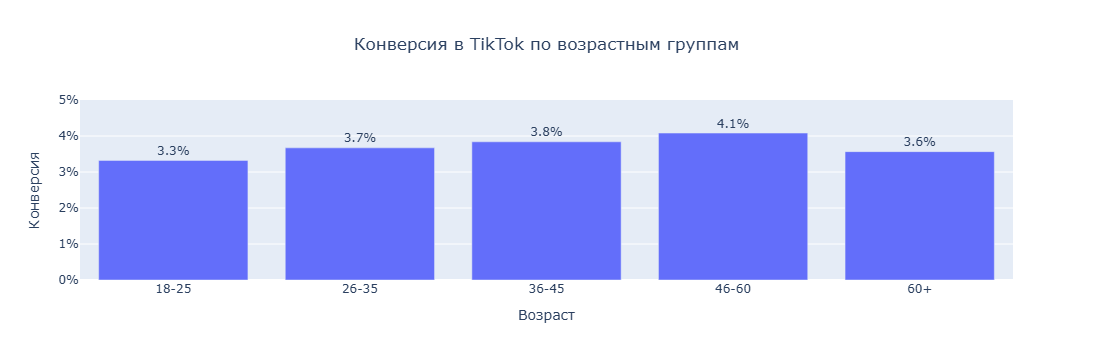

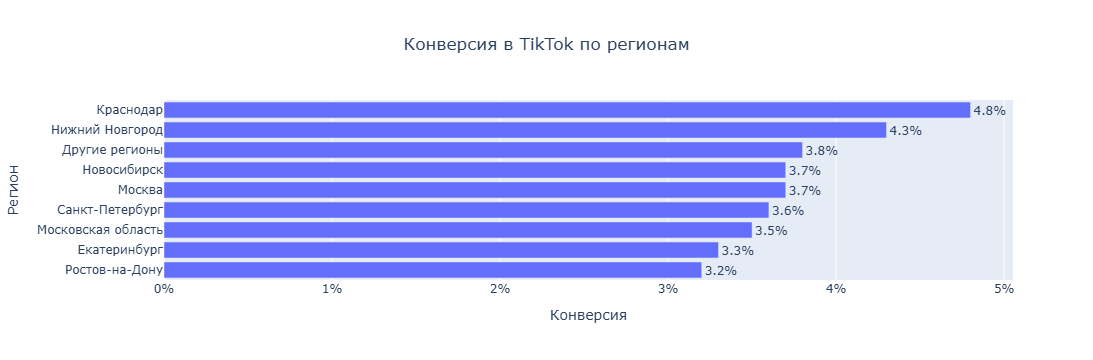

In [37]:
# Исследуем структуру аудитории TikTok по возрасту и регионам
# Создаем возрастные категории
tiktok_users = user_base[user_base['acq_channel'] == 'TikTok'].copy()

bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
tiktok_users['age_group'] = pd.cut(tiktok_users['age'], bins=bins, labels=labels)

# Визуализируем конверсию в платящих пользователей канала TikTok по возрасту
age_conv = tiktok_users.groupby('age_group', as_index=False)['is_payer'].mean().rename(columns={'is_payer': 'conversion'})

fig = px.bar(age_conv, 
             x='age_group', 
             y='conversion',
             title='Конверсия в TikTok по возрастным группам',
             labels={'age_group': 'Возраст', 'conversion': 'Конверсия'})
fig.update_layout(title_x=0.5, yaxis=dict(tickformat='.0%', range=[0, 0.05]))
fig.update_traces(texttemplate='%{y:.1%}', textposition='outside')
fig.show()


# по регионам
region_conv = tiktok_users.groupby('region', as_index=False).agg(
    cnt_users=('is_payer', 'count'),
    conversion=('is_payer', 'mean')).round(3)

fig1 = px.bar(region_conv,
             y='region',
             x='conversion',
             orientation='h',
             title='Конверсия в TikTok по регионам',
             labels={'region': 'Регион', 'conversion': 'Конверсия'})
fig1.update_layout(title_x=0.5,  yaxis={'categoryorder': 'total ascending'}, xaxis_tickformat='.0%')
fig1.update_traces(texttemplate='%{x:.1%}', textposition='outside')
fig1.show()

Анализ возрастных и региональных срезов не выявил сегментов, где TikTok показывал бы приемлемую эффективность — канал провален повсеместно.

### Сегменты товаров

Проанализируем структуру продаж в разрезе товарных категорий. Оценим вклад каждой категории в выручку и объем продаж, а также динамику ключевых категорий в течение года для выявления драйверов роста и зон риска.

#### Вклад категорий в выручку и объём продаж

In [38]:
# Исследуем категории продуктов
category_stats = (pa_marketplace_orders.groupby('category_name', as_index=False)
    .agg(cnt_products=('product_name', 'nunique'),
         sold_units=('quantity', 'sum'),
         revenue=('total_price', 'sum'))).sort_values('revenue', ascending=False)

category_stats['avg_price'] = (category_stats['revenue'] / category_stats['sold_units']).round(2)
category_stats['revenue_share'] = (category_stats['revenue'] / category_stats['revenue'].sum()).round(3)
category_stats['units_share'] = (category_stats['sold_units'] / category_stats['sold_units'].sum()).round(3)

display(category_stats)

,category_name,cnt_products,sold_units,revenue,avg_price,revenue_share,units_share
11,Мебель для дома,8,1964,71619964.45,36466.38,0.163,0.031
2,Бытовая техника,8,2059,44978661.11,21844.91,0.102,0.033
24,Украшения и часы,8,2058,34365942.06,16698.71,0.078,0.033
18,Спортивный инвентарь,8,2021,23307222.90,11532.52,0.053,0.032
23,Товары для туризма,8,1949,22746355.71,11670.78,0.052,0.031
0,Автотовары,8,2123,20896434.84,9842.88,0.047,0.034
21,Товары для кухни,8,2462,20608036.11,8370.45,0.047,0.039
15,Обувь мужская,8,2482,18849633.69,7594.53,0.043,0.039
20,Сумки и аксессуары,8,2311,17469822.79,7559.42,0.040,0.037
14,Обувь женская,8,2424,17209783.72,7099.75,0.039,0.039


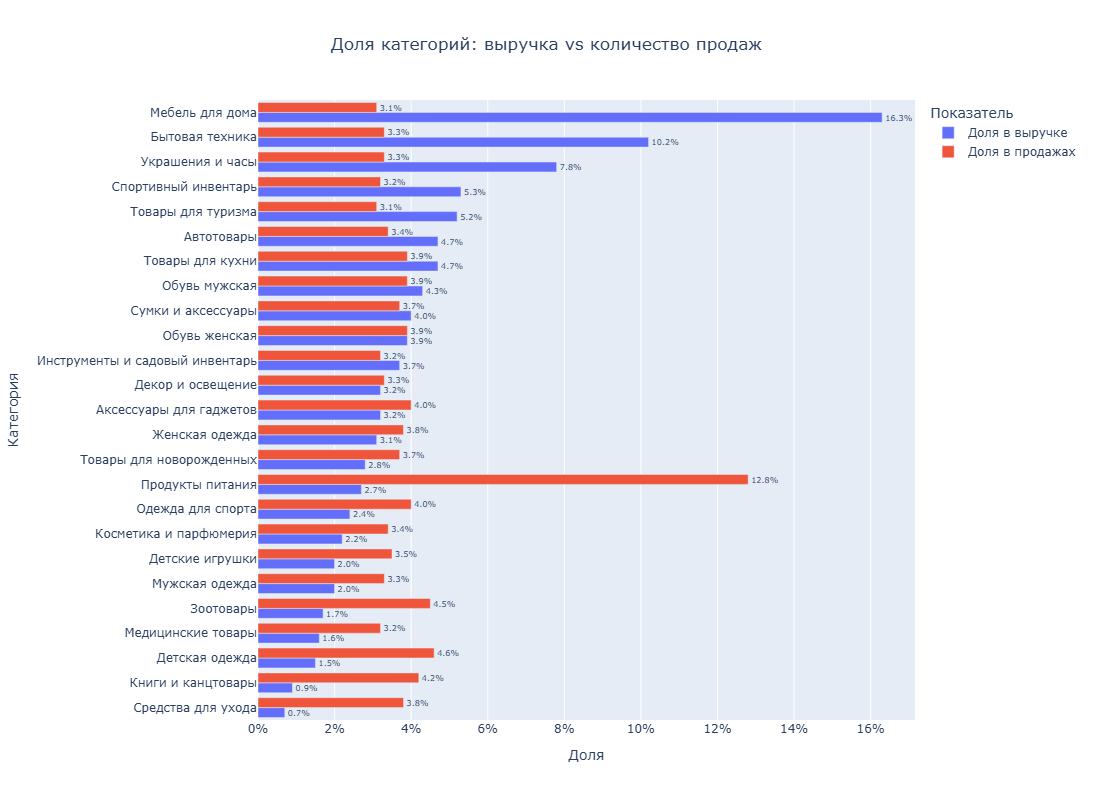

In [39]:
# Визуализируем распределение категорий по доле выручке и проданного товара
category_long = category_stats.melt(id_vars=['category_name'], 
                                    value_vars=['revenue_share', 'units_share'],
                                    var_name='metric', 
                                    value_name='share')


category_long['metric'] = category_long['metric'].map({'revenue_share': 'Доля в выручке', 'units_share': 'Доля в продажах'})

order = category_stats['category_name'].tolist()

fig = px.bar(category_long,
             y='category_name',
             x='share',
             color='metric',
             orientation='h',
             barmode='group',
             title='Доля категорий: выручка vs количество продаж',
             labels={'category_name': 'Категория', 
                     'share': 'Доля',
                     'metric': 'Показатель'},
             text='share',
             category_orders={'category_name': order},
            hover_data={'share': ':.1%'})

fig.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig.update_layout(title_x=0.5, height=800, xaxis=dict(tickformat='.0%'))
fig.show()

- Количество продуктов одинаково (8) во всех категориях.
- Лидеры по выручке (мебель, техника, украшения) имеют высокую среднюю цену (от 16 до 36 тыс. у.е.) при скромном количестве проданных единиц. Это дорогой, но штучный товар.
- Средние категории (спорт, туризм, автотовары, кухня) продают больше единиц (2000–2500), но по более низкой цене (8–12 тыс. у.е.) — массовый, но не дешёвый сегмент.
- Продукты питания — абсолютный рекордсмен по количеству проданных единиц (более 8000) при самой низкой цене (1500 у.е.). Это оборотный, но низкомаржинальный товар.
- Аутсайдеры (средства для ухода, книги, детская одежда) продаются хорошо (2000–2800 единиц), но по низкой цене (1300–2200 у.е.), что даёт им минимальный вклад в выручку.

Структура выручки поляризована: несколько дорогих категорий (мебель, техника, украшения) формируют основу, а массовые низкомаржинальные товары (продукты, книги, средства ухода) — только объём, но не деньги. Устойчивость бизнеса зависит от спроса на дорогие категории.

#### Динамика топ-категорий

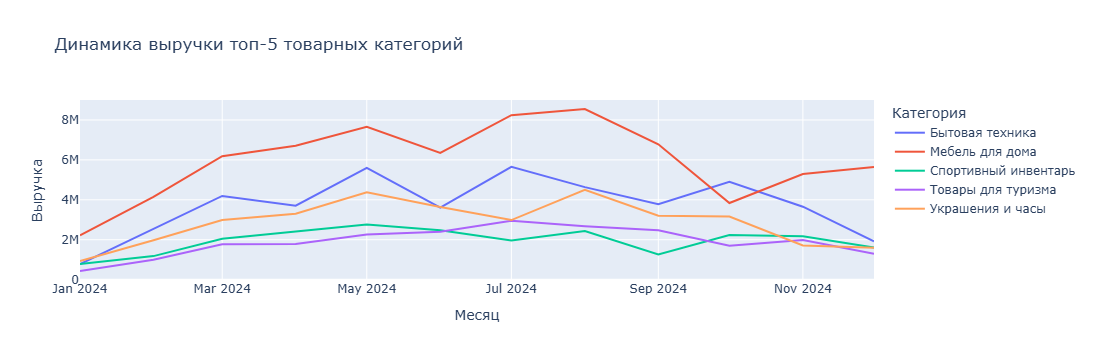

In [40]:
# Оцениваем динамику выручки топ-5 категорий
top_categories = category_stats['category_name'][:5].to_list()

orders_filtered = pa_marketplace_orders.query('category_name in @top_categories')

category_dymanic = (orders_filtered.groupby(['category_name', 'order_month'], as_index=False, observed=True)['total_price']
    .sum()
    .rename(columns={'total_price': 'revenue'}))

# Визуализируем динамику выручки
fig = px.line(category_dymanic,
              x='order_month',
              y='revenue',
              color='category_name',
              title='Динамика выручки топ-5 товарных категорий',
              labels={'order_month': 'Месяц', 'revenue': 'Выручка', 'category_name': 'Категория'},
              hover_data={'revenue': ':.2s'})
fig.show()

- Мебель для дома демонстрирует устойчивость: после спада в октябре выручка в ноябре–декабре вновь идёт вверх, частично отыгрывая падение и возвращаясь к уровням весны. Однако летние пиковые значения (июль–август) остаются недостигнутыми.
- Бытовая техника и украшения, напротив, к декабрю теряют более половины пиковых значений. Их выручка в конце года опускается до уровня января–февраля, что указывает на критическую просадку именно в этих сегментах.
- Спортивный инвентарь и товары для туризма показывают стабильные, но умеренные объёмы, оставаясь в роли "второго эшелона". Их динамика не оказывает решающего влияния на общий результат.

### Анализ пользовательской воронки

Проанализируем воронку пользовательского пути от регистрации до покупки. Оценим конверсию на ключевых этапах, выявим точки наибольших потерь и проверим, различается ли поведение пользователей в зависимости от устройства, операционной системы, канала привлечения и когорты.

Из-за отсутствия временных меток в событиях построение классической воронки с последовательными этапами невозможно. Мы можем оценить только охват аудитории на различных этапах, но не порядок прохождения.

In [41]:
# Отбираем события для воронки
events = ['registration', 'page_view', 'product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete', 'order_complete']
users = pa_marketplace_users['user_id'].unique()

user_events = pa_marketplace_events[['user_id', 'event_type']].drop_duplicates(keep='first').query('event_type in @events and user_id in @users')
user_orders = pd.DataFrame({'user_id': pa_marketplace_orders.query('user_id in @users')['user_id'].unique(), 'event_type': 'order_complete'})
user_registration = pd.DataFrame({'user_id': pa_marketplace_users['user_id'].unique(), 'event_type': 'registration'})

# Объединяем события, добавляем признаки
funnel_data = pd.concat([user_events, user_orders, user_registration])

funnel_data = funnel_data.merge(pa_marketplace_users[['user_id', 'cohort_month', 'acq_channel']], on='user_id', how='right')
funnel_data = funnel_data.merge(pa_marketplace_events[['user_id', 'os', 'device']].drop_duplicates(subset=['user_id'], keep='first'),
                                on='user_id',
                                how='left')

funnel_data['event_type'] = pd.Categorical(funnel_data['event_type'], categories=events, ordered=True)
funnel_data = funnel_data.reset_index(drop=True)
funnel_data = funnel_data.sort_values(['user_id', 'event_type']).reset_index(drop=True)

display(funnel_data.info())
display(funnel_data.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 166777 entries, 0 to 166776
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       166777 non-null  int32         
 1   event_type    166777 non-null  category      
 2   cohort_month  166777 non-null  datetime64[us]
 3   acq_channel   166777 non-null  category      
 4   os            142644 non-null  category      
 5   device        142644 non-null  category      
dtypes: category(4), datetime64[us](1), int32(1)
memory usage: 2.5 MB


None

,user_id,event_type,cohort_month,acq_channel,os,device
0,1,registration,2024-01-01,Google Ads,NaN,NaN
1,2,registration,2024-01-01,Email Marketing,iOS,desktop
2,2,page_view,2024-01-01,Email Marketing,iOS,desktop
3,2,product_view,2024-01-01,Email Marketing,iOS,desktop
4,2,product_click,2024-01-01,Email Marketing,iOS,desktop
5,2,add_to_cart,2024-01-01,Email Marketing,iOS,desktop
6,2,checkout_start,2024-01-01,Email Marketing,iOS,desktop
7,3,registration,2024-01-01,Google Ads,Android,mobile
8,3,page_view,2024-01-01,Google Ads,Android,mobile
9,3,product_view,2024-01-01,Google Ads,Android,mobile


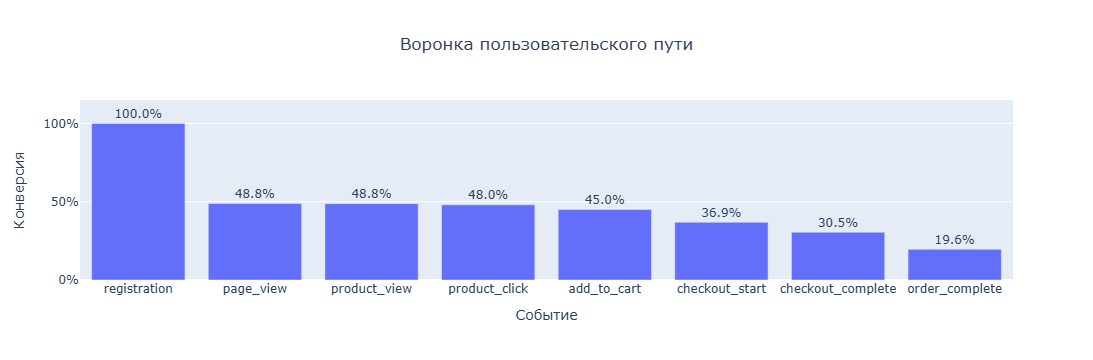

In [42]:
# Визуализируем общую воронку пользовательского пути
funnel = funnel_data.groupby('event_type', as_index=False)['user_id'].count()

funnel['conversion'] = funnel['user_id'] / funnel['user_id'][0] 

fig = px.bar(funnel, 
             x='event_type', 
             y='conversion',
             title='Воронка пользовательского пути',
             labels={'event_type': 'Событие', 'conversion': 'Конверсия'})
fig.update_layout(title_x=0.5, yaxis=dict(tickformat='.0%', range=[0, 1.15]))
fig.update_traces(texttemplate='%{y:.1%}', textposition='outside')
fig.show()

- Провал на входе — половина зарегистрированных пользователей (51%) не начинает просмотр страниц и выбор товара. Это либо слабый onboarding, либо технические проблемы после регистрации.
- Этап корзины → оплата — из тех, кто начал оформление, до оплаты доходит только половина (37% → 20%). Это могут быть проблемы платёжного шлюза, сложность формы или недостаток доверия.
- Ранние этапы (просмотр → корзина) работают хорошо — конверсия 92% среди активных пользователей.

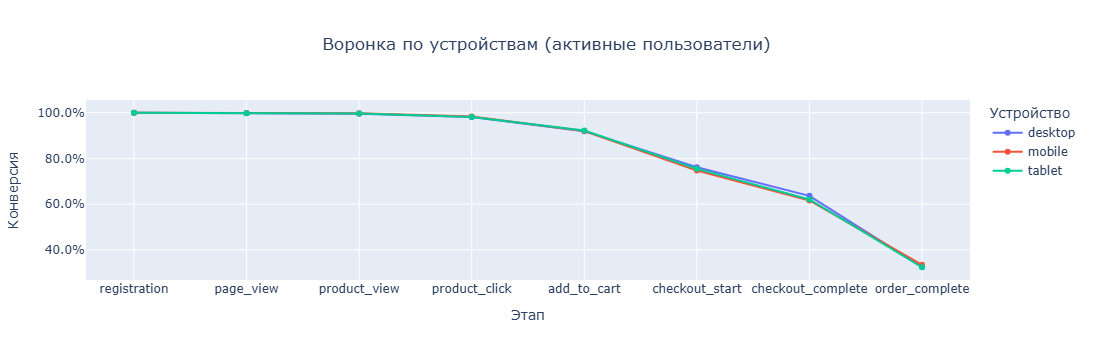

In [43]:
# Визуализируем воронку по устройствам
funnel_device = funnel_data.groupby(['device', 'event_type'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'users'})

funnel_device['first_users'] = funnel_device.groupby('device')['users'].transform('first')
funnel_device['conversion'] = funnel_device['users'] / funnel_device['first_users']

fig = px.line(funnel_device, 
              x='event_type', 
              y='conversion', 
              color='device',
              title='Воронка по устройствам (активные пользователи)',
              labels={'event_type': 'Этап', 'conversion': 'Конверсия', 'device': 'Устройство'},
              markers=True)
fig.update_layout(title_x=0.5, yaxis_tickformat='.1%')
fig.show()

Все три типа устройств (desktop, mobile, tablet) демонстрируют практически идентичную динамику на всех этапах воронки.
Разница в конверсии между устройствами не превышает 1–2%, что позволяет говорить об отсутствии значимого влияния типа устройства на поведение пользователей.

Ключевые этапы потерь одинаковы для всех устройств:
- Корзина → оформление: конверсия падает с ~92% до ~76% (потеря 16%)
- Оформление → завершение оформления: с ~76% до ~63% (потеря 13%)
- Завершение оформления → оплата: с ~63% до 32–33% (потеря 30–31%)

Финальная конверсия в оплаченный заказ от регистрации составляет 32–33% для всех устройств, что указывает на то, что проблемы с оплатой носят системный характер и не зависят от устройства пользователя.

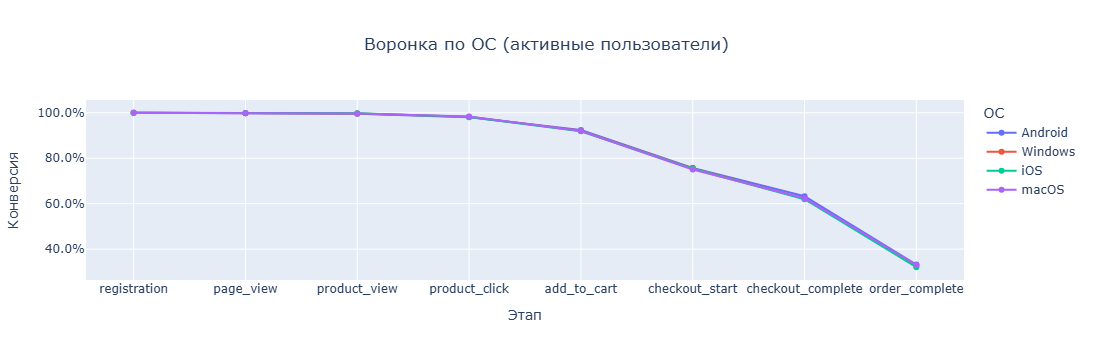

In [44]:
# Визуализируем воронку по ОС
funnel_os = funnel_data.groupby(['os', 'event_type'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'users'})

funnel_os['first_users'] = funnel_os.groupby('os')['users'].transform('first')
funnel_os['conversion'] = funnel_os['users'] / funnel_os['first_users']

fig = px.line(funnel_os, 
              x='event_type', 
              y='conversion', 
              color='os',
              title='Воронка по ОС (активные пользователи)',
              labels={'event_type': 'Этап', 'conversion': 'Конверсия', 'os': 'ОС'},
              markers=True)
fig.update_layout(title_x=0.5, yaxis_tickformat='.1%')
fig.show()

Все операционные системы (Android, Windows, iOS, macOS) демонстрируют идентичную динамику на всех этапах воронки.
Разница в конверсии между ОС не превышает 1–2%, что подтверждает: поведение пользователей не зависит от платформы.

Ключевые этапы потерь одинаковы для всех ОС:
- Корзина → оформление: с ~92% до ~75% (потеря 17%)
- Оформление → завершение: с ~75% до ~62% (потеря 13%)
- Завершение → оплата: с ~62% до 32–33% (потеря 30%)

Финальная конверсия в оплаченный заказ от регистрации составляет 32–33% для всех ОС, что подтверждает: проблема с оплатой носит системный характер и не зависит от операционной системы пользователя.

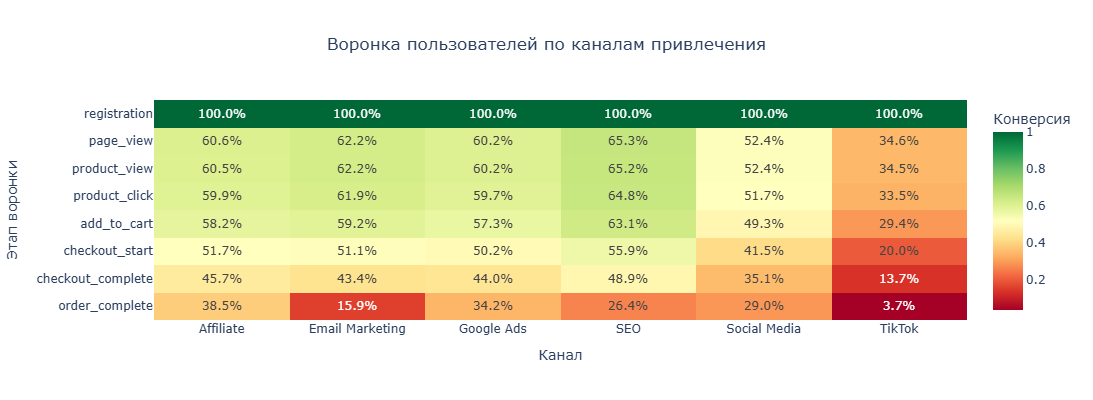

In [45]:
# Визуализируем воронку для каналов привлечения
funnel_channels = funnel_data.groupby(['acq_channel', 'event_type'], as_index=False, observed=True)['user_id'].nunique()
funnel_channels['conversion'] = (funnel_channels['user_id'] / funnel_channels.groupby('acq_channel')['user_id'].transform('first')).round(3)
pivot_funnel_channels = funnel_channels.pivot(index='event_type', columns='acq_channel', values='conversion')

fig = px.imshow(pivot_funnel_channels,
                title='Воронка пользователей по каналам привлечения',
                labels=dict(x='Канал',
                            y='Этап воронки',
                            color='Конверсия'),
                color_continuous_scale='RdYlGn',
                text_auto='.1%',
                aspect='auto')
            
fig.update_layout(title_x=0.5, height=400, xaxis_title='Канал', yaxis_title='Этап воронки')
fig.show()

- Affiliate, Google Ads и SEO — безусловные лидеры по качеству трафика. Они стабильно ведут пользователя от регистрации до оплаты, обеспечивая наивысшую финальную конверсию среди всех каналов.
- Email Marketing и Social Media работают на среднем уровне, но требуют оценки рентабельности с учётом затрат.
- TikTok — критически неэффективен. Канал проваливается уже на старте: лишь треть зарегистрированных пользователей совершает хотя бы одно действие. Финальная конверсия в оплату стремится к нулю.

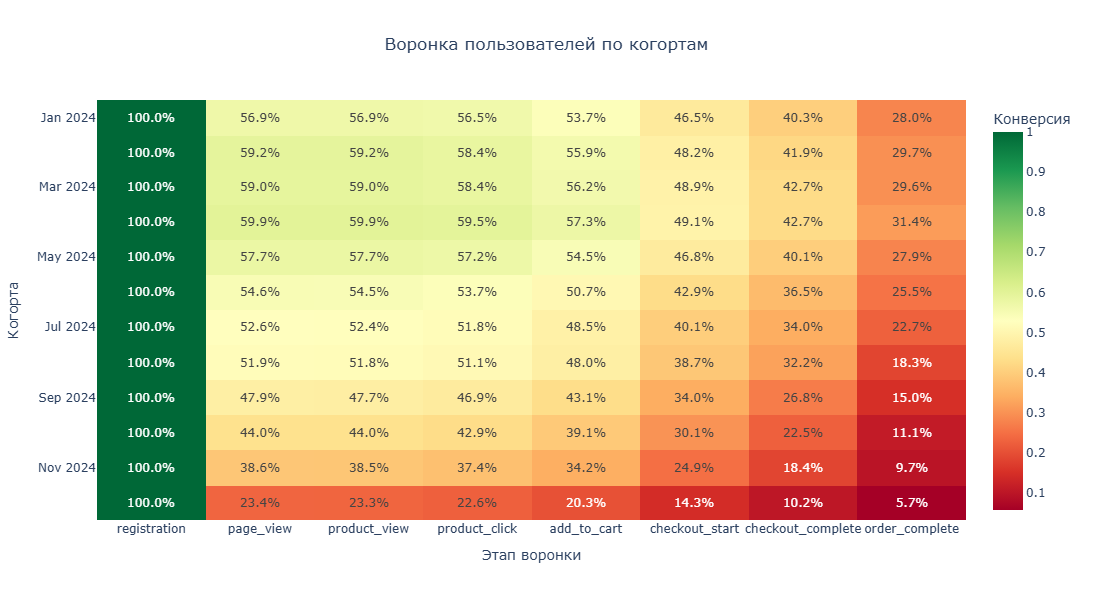

In [46]:
# Визуализируем воронку для когорт
funnel_cohort = funnel_data.groupby(['cohort_month', 'event_type'], as_index=False, observed=True)['user_id'].nunique()
funnel_cohort['conversion'] = (funnel_cohort['user_id'] / funnel_cohort.groupby('cohort_month')['user_id'].transform('first')).round(3)
pivot_funnel_cohort = funnel_cohort.pivot(index='cohort_month', columns='event_type', values='conversion')

fig = px.imshow(pivot_funnel_cohort,
                title='Воронка пользователей по когортам',
                labels=dict(x='Этап воронки',
                            y='Когорта',
                            color='Конверсия'),
                color_continuous_scale='RdYlGn',
                text_auto='.1%',
                aspect='auto')

fig.update_layout(title_x=0.5, height=600, xaxis_title='Этап воронки', yaxis_title='Когорта')
fig.show()

Конверсия пользователей стабильно высока в первом полугодии и неуклонно снижается к концу года.
Ранние когорты (январь–апрель) демонстрируют финальную конверсию в оплату на уровне 28–31%, тогда как декабрьская когорта падает до 5,7%.

Падение начинается уже на первом этапе: доля активных пользователей (достигших просмотра страницы) снижается с 57–59% в начале года до 23% в декабре. Это указывает на то, что поздние когорты хуже вовлекаются в продукт с самого старта.

Основная причина — не в продукте, а в каналах привлечения.
Вероятно, во втором полугодии бюджет был перераспределён в пользу неэффективных каналов (TikTok), которые приводят «холодную» аудиторию, не готовую к покупке.

### Анализ промо-активности

Оценим активность промо-механик на платформе. Проанализируем долю промо-событий в общем трафике и их динамику в течение года для понимания интенсивности промо-активности.

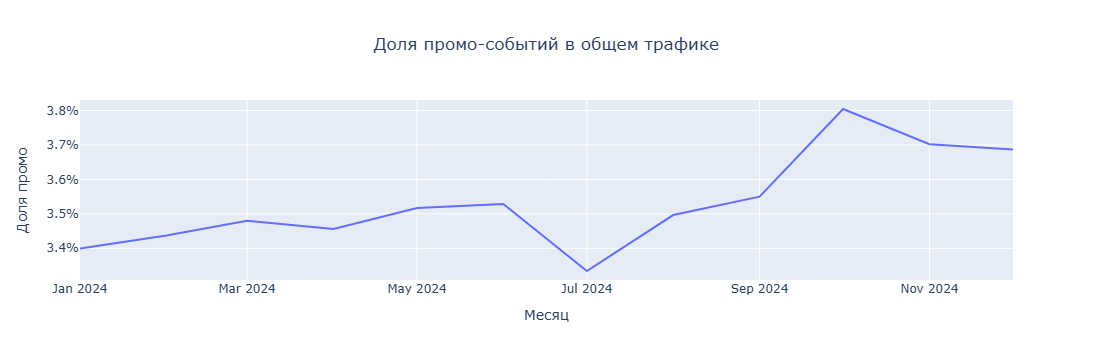

In [47]:
# Исследуем динамику доли промо-событий
promo_events = ['promo_view', 'banner_click']

monthly_events = pa_marketplace_events.groupby('event_month').size().reset_index(name='total_events')
monthly_promo = (pa_marketplace_events[pa_marketplace_events['event_type'].isin(promo_events)]
    .groupby('event_month')
    .size()
    .reset_index(name='promo_events'))

monthly_promo_share = monthly_events.merge(monthly_promo, on='event_month', how='left').fillna(0)
monthly_promo_share['promo_share'] = monthly_promo_share['promo_events'] / monthly_promo_share['total_events']

fig = px.line(monthly_promo_share, 
              x='event_month', 
              y='promo_share',
              title='Доля промо-событий в общем трафике',
              labels={'event_month': 'Месяц', 'promo_share': 'Доля промо'})
fig.update_layout(title_x=0.5, yaxis_tickformat='.1%')
fig.show()

Доля промо-событий стабильна на протяжении всего года и держится в узком диапазоне 3,3–3,8%.
Никакого спада или роста в высокий сезон не наблюдается — промо-кампании работают в одном и том же режиме с января по декабрь.

## Ключевые выводы исторического анализа

### Что произошло с бизнесом

В 2024 году маркетплейс столкнулся с парадоксальной ситуацией: при росте маркетинговых бюджетов в 1,5 раза (с 1,2 до 1,8 млн у.е. в месяц) выручка во втором полугодии упала на 48% относительно пиковых значений (с 2,5 млн у.е. в августе до 1,3 млн у.е. в декабре). Компания стала привлекать больше пользователей, но их качество системно ухудшалось.

**Ключевые метрики подтверждают это:**

| Показатель | Пик (1-е полугодие) | Декабрь | Изменение |
|---|---|---|---|
| Конверсия в платящих | 43% (апрель) | 24% | **−19 п.п.** |
| ARPU | 748 у.е. (май) | 402 у.е. | **−46%** |
| Stickiness (DAU/MAU) | 11% | 8% | **−3 п.п.** |
| ROMI | положительный | отрицательный | — |
| Срок окупаемости когорт | 1 месяц | 2+ месяца | **рост** |


### Где корень проблемы

**1. Падение качества трафика** — главная причина ухудшения всех метрик. При стабильном CAC (390–410 у.е.) ARPU снизился почти вдвое, а конверсия в платящих пользователей упала с 43% до 24%. Это означает, что вложения в привлечение перестали окупаться.

**2. Структурный сдвиг в каналах привлечения**:
- TikTok поглотил 44% всего трафика, но его доля в выручке составила менее 4%. Конверсия на этом канале упала с 3–5% в первом полугодии до 1,8% в декабре.
- Google Ads и Affiliate, напротив, демонстрировали стабильную конверсию 30–40%, но их доля в трафике была значительно сокращена во втором полугодии.

**3. Провалы в воронке (сквозные, не зависят от устройств и ОС):**
- 51% зарегистрированных пользователей не совершают ни одного просмотра страницы или выбора товара.
- На этапе корзина → оплата теряется 30% пользователей.

**4. Товарная структура неустойчива**:
- Мебель, техника и украшения формируют основную выручку.
- Техника и украшения к декабрю потеряли >50% пиковых значений, мебель осталась стабильна.

### Что делать: гипотезы для развития продукта

**Гипотеза 1. Пересмотреть маркетинговую стратегию (каналы)**<br>
Если перераспределить бюджет из TikTok в Affiliate, Google Ads и SEO, то конверсия в оплату среди новых пользователей вернётся к уровням первого полугодия (40%), а не останется на уровне 24%.<br>
*Основание:* в первом полугодии эти каналы обеспечивали высокую конверсию, во втором — их доля снизилась, а качество трафика упало.

**Гипотеза 2. Улучшить онбординг**<br>
Если внедрить приветственную серию писем или промокод на первый заказ для пользователей, которые зарегистрировались, но не совершили ни одного действия, то долю активных пользователей можно увеличить за счёт возврата «спящей» аудитории.<br>
*Основание:* 51% зарегистрированных пользователей не совершают ни одного действия.

**Гипотеза 3. Оптимизировать этап оплаты**<br>
Если упростить форму оплаты, добавить альтернативные способы (например, оплату частями) и проверить работу платёжного шлюза, то конверсия из завершения оформления в оплаченный заказ вырастет.<br>
*Основание:* на этапе оплаты теряется 30% пользователей, причём эта проблема одинакова для всех устройств и каналов.

**Гипотеза 4. Сбалансировать ассортимент**<br>
Если в ноябре–декабре усилить промо техники и украшений, которые проседают в этот период, можно сгладить общее падение выручки и снизить зависимость от одной категории.<br>
*Основание:* мебель остаётся стабильной, а техника и украшения теряют до половины выручки к концу года.


### Что требует немедленного внимания

**1. Аудит системы логирования**  
3,6% платящих пользователей не видны в `events`, что делает невозможным анализ их поведения. Это может быть технической ошибкой (потеря событий) или особенностью трекинга (например, часть пользователей заходит только через мобильное приложение, где логируются не все события). Требуется аудит сбора данных.

**2. Аномально низкая конверсия на этапе оплаты**  
На этапе «оформление заказа → оплата» теряется около 30% пользователей. Это может быть связано с:
- проблемами платёжного шлюза (сбои, долгая обработка)
- неудобной формой оплаты (отсутствие альтернативных способов, сложный интерфейс)
- недостатком доверия к платформе
- техническими ограничениями (например, не все способы оплаты доступны в определённых регионах)

Рекомендуется провести отдельное исследование: user testing формы оплаты, анализ отказов по типам ошибок, A/B-тест упрощённой формы.

**3. Мониторинг каналов в реальном времени**  
Бюджет перетекает в заведомо убыточные каналы (TikTok), в то время как эффективные (Affiliate, Google Ads) теряют финансирование. Необходимо настроить алерты на падение ROMI и еженедельный ревью бюджетов.

### Следующий шаг

На основе анализа команда выдвинула гипотезу о влиянии бонуса на первую покупку для пользователей TikTok. Результаты A/B-теста представлены в следующем разделе.